# Quiz: Stochastic Process Simulations

This notebook simulates and compares four discrete-time stochastic systems:
1. AWGN filtered by a low-pass system $H(\omega)$
2. AR(3) process
3. ARMA(3, 6) process
4. Random Walk process

Each part includes a short analytical model and an empirical time-domain simulation.

In [77]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from numpy.typing import NDArray

plt.style.use("seaborn-v0_8-whitegrid")


def design_fir_lpf(
    sample_rate_hz: float,  # Sampling frequency [Hz]
    cutoff_hz: float,  # Low-pass cutoff frequency [Hz]
    num_taps: int,  # FIR length [samples], must be odd
) -> NDArray[np.float64]:  # FIR impulse response h[n] with unit DC gain
    """Designs a linear-phase FIR LPF approximation to H(w) using windowed-sinc.

    Purpose:
        Build a practical discrete-time LPF for filtering white Gaussian noise.

    Parameters:
        sample_rate_hz: Sampling frequency in Hz.
        cutoff_hz: Desired cutoff frequency in Hz.
        num_taps: Number of FIR coefficients (odd for symmetry).

    Returns:
        Real FIR coefficients h[n], normalized to preserve DC gain.

    Side effects:
        None.
    """
    if sample_rate_hz <= 0.0:
        raise ValueError("sample_rate_hz must be positive.")
    if not (0.0 < cutoff_hz < sample_rate_hz / 2.0):
        raise ValueError("cutoff_hz must be in (0, sample_rate_hz/2).")
    if num_taps < 3 or num_taps % 2 == 0:
        raise ValueError("num_taps must be an odd integer >= 3.")

    # Create a centered index and ideal LPF impulse response.
    n: NDArray[np.float64] = np.arange(num_taps, dtype=np.float64)
    center: float = (num_taps - 1) / 2.0
    normalized_cutoff: float = cutoff_hz / sample_rate_hz
    h_ideal: NDArray[np.float64] = (
        2.0
        * normalized_cutoff
        * np.sinc(2.0 * normalized_cutoff * (n - center))
    )

    # Apply a Hamming window to reduce sidelobes and normalize DC gain.
    h_windowed: NDArray[np.float64] = h_ideal * np.hamming(num_taps)
    h_windowed /= np.sum(h_windowed)
    return h_windowed.astype(np.float64)


def simulate_ar3(
    num_samples: int,  # Number of output samples [samples]
    ar_coeffs: tuple[float, float, float],  # (a1, a2, a3) in AR recursion
    noise_std: float = 1.0,  # Innovation standard deviation
    burn_in_samples: int = 500,  # Discarded warm-up samples [samples]
    random_seed: int = 0,  # Seed for reproducibility
) -> NDArray[np.float64]:  # Simulated AR(3) sequence
    """Simulates a stationary AR(3) process with Gaussian innovations.

    Purpose:
        Generate x[n] = a1 x[n-1] + a2 x[n-2] + a3 x[n-3] + w[n],
        where w[n] is zero-mean white Gaussian noise.

    Parameters:
        num_samples: Final sequence length after burn-in.
        ar_coeffs: AR recursion coefficients (a1, a2, a3).
        noise_std: Standard deviation of w[n].
        burn_in_samples: Warm-up length discarded to reduce transients.
        random_seed: Seed controlling deterministic simulation.

    Returns:
        Length-`num_samples` AR(3) realization.

    Side effects:
        None.
    """
    if num_samples <= 0:
        raise ValueError("num_samples must be positive.")
    if noise_std <= 0.0:
        raise ValueError("noise_std must be positive.")
    if burn_in_samples < 0:
        raise ValueError("burn_in_samples must be non-negative.")

    a1, a2, a3 = ar_coeffs
    total_samples: int = num_samples + burn_in_samples

    # Draw innovations and run causal recursion from n=3 onward.
    rng = np.random.default_rng(seed=random_seed)
    innovations: NDArray[np.float64] = rng.normal(
        loc=0.0,
        scale=noise_std,
        size=total_samples,
    ).astype(np.float64)
    x: NDArray[np.float64] = np.zeros(total_samples, dtype=np.float64)

    for n_idx in range(3, total_samples):
        x[n_idx] = (
            a1 * x[n_idx - 1]
            + a2 * x[n_idx - 2]
            + a3 * x[n_idx - 3]
            + innovations[n_idx]
        )

    return x[burn_in_samples:]


def simulate_arma36(
    num_samples: int,  # Number of output samples [samples]
    ar_coeffs: tuple[float, float, float],  # AR coefficients (a1, a2, a3)
    ma_coeffs: tuple[float, float, float, float, float, float],  # MA coefficients (b1..b6)
    noise_std: float = 1.0,  # Innovation standard deviation
    burn_in_samples: int = 500,  # Discarded warm-up samples [samples]
    random_seed: int = 0,  # Seed for reproducibility
) -> NDArray[np.float64]:  # Simulated ARMA(3,6) sequence
    """Simulates an ARMA(3,6) process with Gaussian innovations.

    Purpose:
        Generate x[n] = sum(a_k x[n-k]) + w[n] + sum(b_m w[n-m])
        using AR lags k=1..3 and MA lags m=1..6.

    Parameters:
        num_samples: Final sequence length after burn-in.
        ar_coeffs: AR recursion coefficients (a1, a2, a3).
        ma_coeffs: MA coefficients (b1, ..., b6).
        noise_std: Standard deviation of w[n].
        burn_in_samples: Warm-up length discarded to reduce transients.
        random_seed: Seed controlling deterministic simulation.

    Returns:
        Length-`num_samples` ARMA(3,6) realization.

    Side effects:
        None.
    """
    if num_samples <= 0:
        raise ValueError("num_samples must be positive.")
    if noise_std <= 0.0:
        raise ValueError("noise_std must be positive.")
    if burn_in_samples < 0:
        raise ValueError("burn_in_samples must be non-negative.")
    if len(ar_coeffs) != 3:
        raise ValueError("ar_coeffs must have length 3 for ARMA(3,6).")
    if len(ma_coeffs) != 6:
        raise ValueError("ma_coeffs must have length 6 for ARMA(3,6).")

    a1, a2, a3 = ar_coeffs
    b1, b2, b3, b4, b5, b6 = ma_coeffs

    # Keep six extra innovation samples for MA lags at startup.
    total_samples: int = num_samples + burn_in_samples + 6
    rng = np.random.default_rng(seed=random_seed)
    innovations: NDArray[np.float64] = rng.normal(
        loc=0.0,
        scale=noise_std,
        size=total_samples,
    ).astype(np.float64)
    x: NDArray[np.float64] = np.zeros(total_samples, dtype=np.float64)

    for n_idx in range(6, total_samples):
        # AR term models recursive memory from past outputs.
        ar_term: float = (
            a1 * x[n_idx - 1]
            + a2 * x[n_idx - 2]
            + a3 * x[n_idx - 3]
        )
        # MA term shapes current sample using current and delayed innovations.
        ma_term: float = (
            innovations[n_idx]
            + b1 * innovations[n_idx - 1]
            + b2 * innovations[n_idx - 2]
            + b3 * innovations[n_idx - 3]
            + b4 * innovations[n_idx - 4]
            + b5 * innovations[n_idx - 5]
            + b6 * innovations[n_idx - 6]
        )
        x[n_idx] = ar_term + ma_term

    return x[burn_in_samples + 6 :]



def welch_psd_torch(
    signal_samples: NDArray[np.float64],  # Input realization x[n]
    sample_rate_hz: float,  # Sampling frequency [Hz]
    segment_length_samples: int = 512,  # Welch segment length [samples]
    overlap_samples: int | None = None,  # Segment overlap [samples]
) -> tuple[NDArray[np.float64], NDArray[np.float64]]:  # (frequency_hz, PSD)
    """Estimates a one-sided PSD using a Welch method implemented in PyTorch.

    Purpose:
        Provide a deterministic, fully PyTorch-based PSD estimate suitable for
        stochastic-process analysis in this notebook.

    Parameters:
        signal_samples: 1-D discrete-time realization to analyze.
        sample_rate_hz: Sampling frequency in Hz.
        segment_length_samples: Window length used by Welch's method.
        overlap_samples: Overlap between adjacent windows. If ``None``, uses 50% overlap.

    Returns:
        A tuple ``(freq_hz, psd_power_per_hz)`` containing one-sided frequency bins
        and the averaged PSD estimate in power/Hz.

    Side effects:
        None.
    """
    if sample_rate_hz <= 0.0:
        raise ValueError("sample_rate_hz must be positive.")

    x_tensor = torch.as_tensor(signal_samples, dtype=torch.float64)
    if x_tensor.ndim != 1:
        raise ValueError("signal_samples must be one-dimensional.")
    if segment_length_samples <= 0:
        raise ValueError("segment_length_samples must be positive.")
    if x_tensor.numel() < segment_length_samples:
        raise ValueError("segment_length_samples cannot exceed signal length.")

    if overlap_samples is None:
        overlap_samples = segment_length_samples // 2
    if overlap_samples < 0 or overlap_samples >= segment_length_samples:
        raise ValueError(
            "overlap_samples must be in [0, segment_length_samples).",
        )

    # Split x[n] into overlapping segments using stride-based unfolding.
    step_samples: int = segment_length_samples - overlap_samples
    segments = x_tensor.unfold(
        dimension=0,
        size=segment_length_samples,
        step=step_samples,
    )

    # Remove local means and apply a Hann window before FFT.
    segments = segments - torch.mean(segments, dim=1, keepdim=True)
    window = torch.hann_window(
        segment_length_samples,
        periodic=False,
        dtype=torch.float64,
    )
    window_power: torch.Tensor = torch.sum(window**2)
    windowed_segments = segments * window

    # Compute one-sided periodograms and average them (Welch estimate).
    spectrum = torch.fft.rfft(windowed_segments, n=segment_length_samples, dim=1)
    psd_segments = (torch.abs(spectrum) ** 2) / (sample_rate_hz * window_power)

    if segment_length_samples % 2 == 0:
        psd_segments[:, 1:-1] *= 2.0
    else:
        psd_segments[:, 1:] *= 2.0

    psd_mean = torch.mean(psd_segments, dim=0)
    freq_hz = torch.fft.rfftfreq(segment_length_samples, d=1.0 / sample_rate_hz)

    return (
        freq_hz.detach().cpu().numpy().astype(np.float64),
        psd_mean.detach().cpu().numpy().astype(np.float64),
    )



def normalize_process_unit_variance(
    signal_samples: NDArray[np.float64],  # Input realization x[n]
    eps: float = 1e-12,  # Minimum allowed standard deviation
) -> NDArray[np.float64]:  # Zero-mean unit-variance sequence
    """Normalizes a sequence to zero mean and unit variance.

    Purpose:
        Enforce consistent amplitude scaling across time-domain realizations so
        PSD levels can be compared directly.

    Parameters:
        signal_samples: One-dimensional process realization.
        eps: Numerical floor for standard deviation validation.

    Returns:
        Normalized realization with empirical mean approximately zero and
        empirical variance equal to one.

    Side effects:
        None.
    """
    x: NDArray[np.float64] = np.asarray(signal_samples, dtype=np.float64)
    if x.ndim != 1:
        raise ValueError("signal_samples must be one-dimensional.")

    # Remove DC component before setting unit variance.
    x_centered: NDArray[np.float64] = x - float(np.mean(x))
    x_std: float = float(np.std(x_centered, ddof=0))
    if x_std <= eps:
        raise ValueError("signal standard deviation is too small to normalize.")

    return (x_centered / x_std).astype(np.float64)



def prepare_psd_db_for_omega_band(
    freq_hz: NDArray[np.float64],  # One-sided Welch frequency bins [Hz]
    psd_power_per_hz: NDArray[np.float64],  # One-sided PSD estimate [power/Hz]
    omega_max_rad_s: float,  # Maximum plotted angular frequency F [rad/s]
    min_psd_power: float = 1e-18,  # Lower bound before log conversion
) -> tuple[NDArray[np.float64], NDArray[np.float64]]:  # (omega_rad_s, PSD_dB)
    """Converts PSD to normalized dB scale and restricts it to omega in (0, F].

    Purpose:
        Prepare PSD curves for log-frequency plotting with a guaranteed 0 dB
        maximum in the displayed band.

    Parameters:
        freq_hz: One-sided discrete frequency bins from Welch estimation.
        psd_power_per_hz: PSD values associated with ``freq_hz``.
        omega_max_rad_s: Upper angular-frequency limit F for visualization.
        min_psd_power: Lower clipping floor to avoid log(0).

    Returns:
        Tuple ``(omega_rad_s, psd_db)`` where:
        - ``omega_rad_s`` only contains strictly positive values up to F.
        - ``psd_db`` is normalized so its maximum equals exactly 0 dB.

    Side effects:
        None.
    """
    if omega_max_rad_s <= 0.0:
        raise ValueError("omega_max_rad_s must be positive.")

    freq_array_hz: NDArray[np.float64] = np.asarray(freq_hz, dtype=np.float64)
    psd_array: NDArray[np.float64] = np.asarray(psd_power_per_hz, dtype=np.float64)
    if freq_array_hz.ndim != 1 or psd_array.ndim != 1:
        raise ValueError("freq_hz and psd_power_per_hz must be one-dimensional.")
    if freq_array_hz.shape != psd_array.shape:
        raise ValueError("freq_hz and psd_power_per_hz must have the same shape.")

    # Convert to angular frequency and keep only (0, F] for log-omega plotting.
    omega_rad_s: NDArray[np.float64] = 2.0 * np.pi * freq_array_hz
    band_mask: NDArray[np.bool_] = (
        (omega_rad_s > 0.0) & (omega_rad_s <= omega_max_rad_s)
    )
    if not np.any(band_mask):
        raise ValueError("No PSD bins remain inside the requested omega band.")

    omega_band_rad_s: NDArray[np.float64] = omega_rad_s[band_mask]
    psd_band: NDArray[np.float64] = np.maximum(psd_array[band_mask], min_psd_power)

    # Normalize dB level so the displayed maximum is exactly 0 dB.
    psd_band_db: NDArray[np.float64] = 10.0 * np.log10(psd_band)
    psd_band_db -= float(np.max(psd_band_db))

    return (
        omega_band_rad_s.astype(np.float64),
        psd_band_db.astype(np.float64),
    )



def autocorrelation_normalized_torch(
    signal_samples: NDArray[np.float64],  # Input realization x[n]
    max_lag_samples: int = 200,  # Maximum non-negative lag [samples]
    eps: float = 1e-18,  # Numerical guard for near-zero variance
) -> tuple[NDArray[np.int64], NDArray[np.float64]]:  # (lags, normalized_acf)
    """Computes normalized autocorrelation for non-negative lags using PyTorch.

    Purpose:
        Provide a consistent autocorrelation estimate for each normalized process
        so PSD and correlation behavior can be compared in one summary figure.

    Parameters:
        signal_samples: One-dimensional process realization.
        max_lag_samples: Largest lag index included in the result.
        eps: Small positive threshold to avoid division by very small values.

    Returns:
        Tuple ``(lags_samples, acf_normalized)`` where:
        - ``lags_samples`` spans ``0..max_lag_samples``.
        - ``acf_normalized`` equals ``R_x[k] / R_x[0]``.

    Side effects:
        None.
    """
    x_tensor = torch.as_tensor(signal_samples, dtype=torch.float64)
    if x_tensor.ndim != 1:
        raise ValueError("signal_samples must be one-dimensional.")
    if max_lag_samples < 0:
        raise ValueError("max_lag_samples must be non-negative.")

    num_samples: int = int(x_tensor.numel())
    if max_lag_samples >= num_samples:
        raise ValueError("max_lag_samples must be smaller than signal length.")

    # Remove the mean before estimating covariance-based correlations.
    x_centered = x_tensor - torch.mean(x_tensor)

    # Use the biased estimator (divide by N) for stable comparison across lags.
    acf_values = torch.empty(max_lag_samples + 1, dtype=torch.float64)
    for lag_idx in range(max_lag_samples + 1):
        acf_values[lag_idx] = (
            torch.dot(x_centered[: num_samples - lag_idx], x_centered[lag_idx:])
            / num_samples
        )

    acf_at_zero: torch.Tensor = acf_values[0]
    if torch.abs(acf_at_zero) <= eps:
        raise ValueError("autocorrelation at lag zero is too small to normalize.")

    acf_normalized = acf_values / acf_at_zero
    lags_samples = torch.arange(max_lag_samples + 1, dtype=torch.int64)

    return (
        lags_samples.detach().cpu().numpy().astype(np.int64),
        acf_normalized.detach().cpu().numpy().astype(np.float64),
    )

def simulate_random_walk(
    num_samples: int,  # Number of output samples [samples]
    step_std: float = 1.0,  # Standard deviation of random increments
    initial_value: float = 0.0,  # Initial condition before the first increment
    random_seed: int = 0,  # Seed for reproducibility
) -> NDArray[np.float64]:  # Simulated random walk sequence
    """Simulates a Gaussian random walk process.

    Purpose:
        Generate x[n] = x[n-1] + w[n], where w[n] is zero-mean white Gaussian
        increment noise. The model captures cumulative random drift behavior.

    Parameters:
        num_samples: Final sequence length.
        step_std: Standard deviation of increment noise w[n].
        initial_value: Initial walk value before cumulative increments.
        random_seed: Seed controlling deterministic simulation.

    Returns:
        Length-`num_samples` random-walk realization.

    Side effects:
        None.
    """
    if num_samples <= 0:
        raise ValueError("num_samples must be positive.")
    if step_std <= 0.0:
        raise ValueError("step_std must be positive.")

    # Draw Gaussian increments and integrate them with a cumulative sum.
    rng = np.random.default_rng(seed=random_seed)
    increments: NDArray[np.float64] = rng.normal(
        loc=0.0,
        scale=step_std,
        size=num_samples,
    ).astype(np.float64)

    walk: NDArray[np.float64] = np.cumsum(increments, dtype=np.float64)
    walk += float(initial_value)
    return walk


## 1) LPF $H(\omega)$ filtering AWGN (analytical)

Let $x[n] \sim \mathcal{N}(0,\sigma_x^2)$ be white Gaussian noise. For an LTI filter with
impulse response $h[n]$ and frequency response $H(e^{j\omega})$:

$$y[n] = (h * x)[n], \qquad S_y(e^{j\omega}) = |H(e^{j\omega})|^2 S_x(e^{j\omega}).$$

Since white noise has flat spectrum $S_x(e^{j\omega}) = \sigma_x^2$, the LPF attenuates
high-frequency power and reduces output variance according to:

$$\sigma_y^2 = \sigma_x^2 \sum_n h^2[n].$$

Below, $H(\omega)$ is implemented numerically as a windowed-sinc FIR LPF.

LPF output variance (theoretical): 0.1528
LPF output variance (empirical):   0.1516
LPF normalized mean:               +9.474e-18
LPF normalized variance:           1.0000


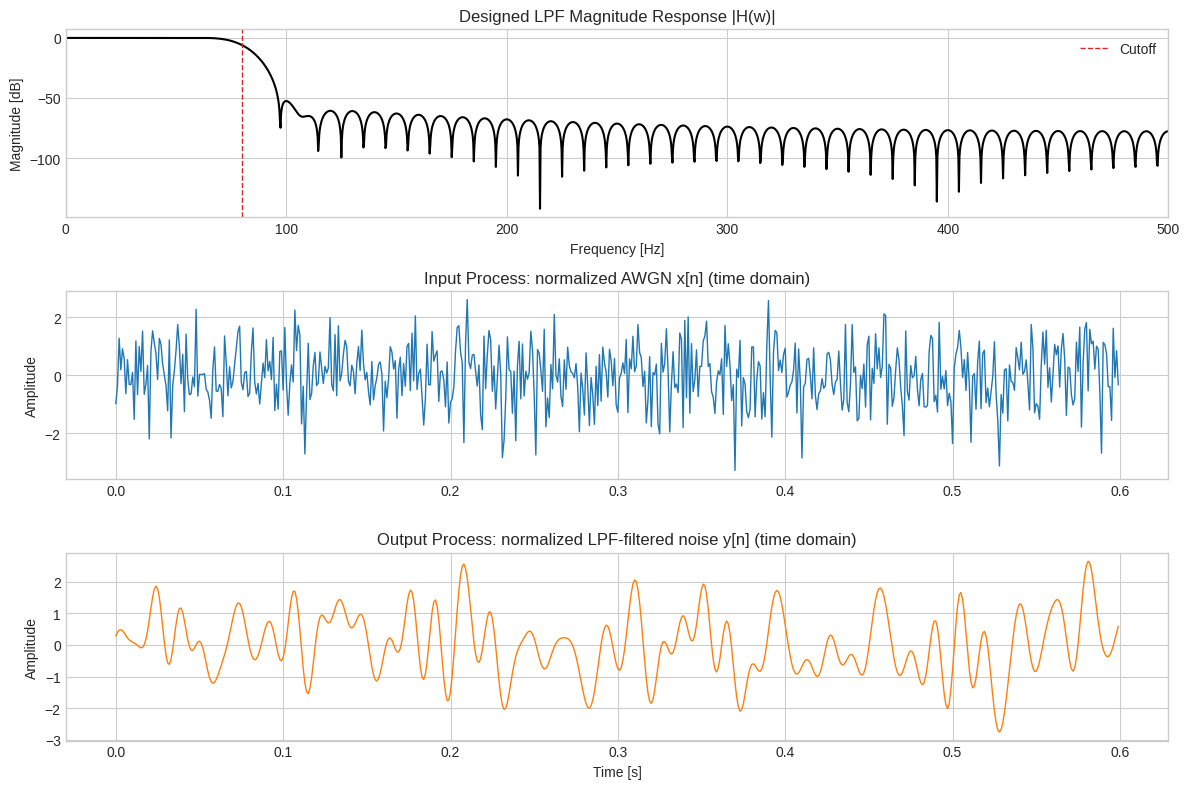

In [78]:
# Simulation parameters with explicit units.
sample_rate_hz: float = 1000.0  # Sampling frequency [Hz]
cutoff_hz: float = 80.0  # LPF cutoff frequency [Hz]
num_taps: int = 101  # FIR length [samples]
num_samples: int = 3000  # Signal length [samples]
noise_std: float = 1.0  # AWGN standard deviation

# Shared plotting parameters for the summary PSD/ACF figure.
omega_plot_limit_rad_s: float = 2.0 * np.pi * 200.0  # F = 2*pi*200 [rad/s]
psd_plot_floor_db: float = -30.0  # Lowest displayed PSD level [dB]
acf_max_lag_samples: int = 200  # Maximum displayed autocorrelation lag [samples]

# Generate AWGN input x[n].
rng_lpf = np.random.default_rng(seed=123)
x_awgn: NDArray[np.float64] = rng_lpf.normal(
    loc=0.0,
    scale=noise_std,
    size=num_samples,
).astype(np.float64)

# Build LPF H(w) and filter x[n] to produce y[n].
h_lpf: NDArray[np.float64] = design_fir_lpf(
    sample_rate_hz=sample_rate_hz,
    cutoff_hz=cutoff_hz,
    num_taps=num_taps,
)
y_lpf: NDArray[np.float64] = np.convolve(x_awgn, h_lpf, mode="same")

# Normalize all time-domain sequences used in this section.
x_awgn_norm: NDArray[np.float64] = normalize_process_unit_variance(x_awgn)
y_lpf_norm: NDArray[np.float64] = normalize_process_unit_variance(y_lpf)

# Compare theoretical and empirical output variance before normalization.
sigma_y2_theoretical: float = (noise_std**2) * float(np.sum(h_lpf**2))
sigma_y2_empirical: float = float(np.var(y_lpf, ddof=0))
print(f"LPF output variance (theoretical): {sigma_y2_theoretical:.4f}")
print(f"LPF output variance (empirical):   {sigma_y2_empirical:.4f}")
print(f"LPF normalized mean:               {np.mean(y_lpf_norm):+.3e}")
print(f"LPF normalized variance:           {np.var(y_lpf_norm, ddof=0):.4f}")

# Compute the discrete frequency response to visualize H(w).
fft_size: int = 4096
h_freq = np.fft.rfft(h_lpf, n=fft_size)
freq_hz: NDArray[np.float64] = np.fft.rfftfreq(
    fft_size,
    d=1.0 / sample_rate_hz,
)

# Plot H(w), normalized AWGN input, and normalized LPF output in time domain.
segment_samples: int = 600
time_s: NDArray[np.float64] = np.arange(num_samples, dtype=np.float64) / sample_rate_hz

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=False)
axes[0].plot(freq_hz, 20.0 * np.log10(np.maximum(np.abs(h_freq), 1e-8)), color="black")
axes[0].axvline(cutoff_hz, color="tab:red", linestyle="--", linewidth=1.0, label="Cutoff")
axes[0].set_title("Designed LPF Magnitude Response |H(w)|")
axes[0].set_ylabel("Magnitude [dB]")
axes[0].set_xlabel("Frequency [Hz]")
axes[0].set_xlim(0.0, sample_rate_hz / 2.0)
axes[0].legend()

axes[1].plot(
    time_s[:segment_samples],
    x_awgn_norm[:segment_samples],
    color="tab:blue",
    linewidth=1.0,
)
axes[1].set_title("Input Process: normalized AWGN x[n] (time domain)")
axes[1].set_ylabel("Amplitude")

axes[2].plot(
    time_s[:segment_samples],
    y_lpf_norm[:segment_samples],
    color="tab:orange",
    linewidth=1.0,
)
axes[2].set_title("Output Process: normalized LPF-filtered noise y[n] (time domain)")
axes[2].set_xlabel("Time [s]")
axes[2].set_ylabel("Amplitude")

plt.tight_layout()
plt.show()

# Estimate PSD of normalized LPF-filtered process for the summary figure.
welch_segment_lpf_samples: int = 512
welch_overlap_lpf_samples: int = 256
freq_lpf_psd_hz, psd_lpf_power_per_hz = welch_psd_torch(
    signal_samples=y_lpf_norm,
    sample_rate_hz=sample_rate_hz,
    segment_length_samples=welch_segment_lpf_samples,
    overlap_samples=welch_overlap_lpf_samples,
)
omega_lpf_rad_s, psd_lpf_db = prepare_psd_db_for_omega_band(
    freq_hz=freq_lpf_psd_hz,
    psd_power_per_hz=psd_lpf_power_per_hz,
    omega_max_rad_s=omega_plot_limit_rad_s,
)


## 2) AR(3) process (analytical)

The AR(3) model is:

$$x[n] = a_1 x[n-1] + a_2 x[n-2] + a_3 x[n-3] + w[n], \quad w[n] \sim \mathcal{N}(0, \sigma_w^2).$$

With $A(z) = 1 - a_1 z^{-1} - a_2 z^{-2} - a_3 z^{-3}$, the transfer function from
innovation to output is $H(z) = 1/A(z)$. A stable AR part yields a stationary process.

Here we use poles $p = \{0.75, -0.45, 0.25\}$ in the recursion design, which gives:

$$a_1 = 0.55, \quad a_2 = 0.2625, \quad a_3 = -0.084375.$$

AR(3) normalized mean: +1.184e-17
AR(3) normalized var:  1.0000


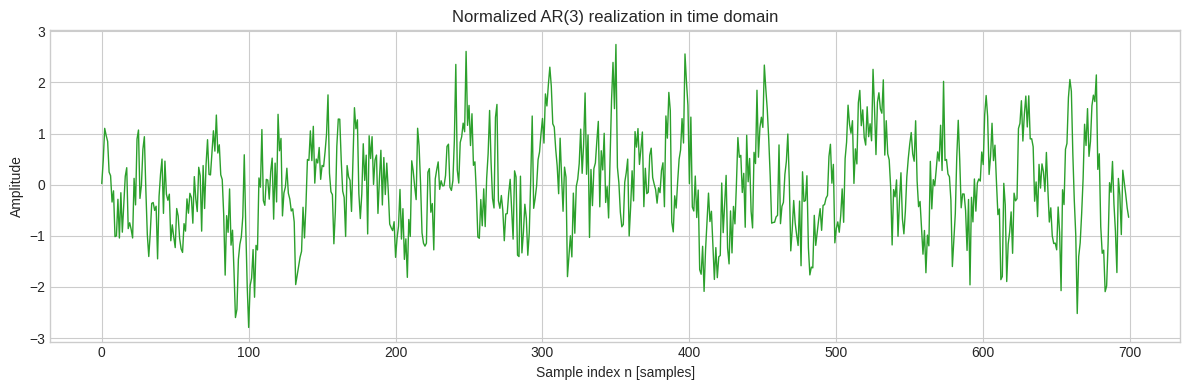

In [79]:
num_samples_ar3: int = 3000  # Output length [samples]
noise_std_ar3: float = 1.0  # Innovation standard deviation
ar3_coeffs: tuple[float, float, float] = (0.55, 0.2625, -0.084375)

x_ar3: NDArray[np.float64] = simulate_ar3(
    num_samples=num_samples_ar3,
    ar_coeffs=ar3_coeffs,
    noise_std=noise_std_ar3,
    burn_in_samples=600,
    random_seed=321,
)

# Normalize the AR(3) realization for consistent time-domain and PSD scaling.
x_ar3_norm: NDArray[np.float64] = normalize_process_unit_variance(x_ar3)

print(f"AR(3) normalized mean: {np.mean(x_ar3_norm):+.3e}")
print(f"AR(3) normalized var:  {np.var(x_ar3_norm, ddof=0):.4f}")

segment_samples_ar3: int = 700
n_ar3: NDArray[np.int64] = np.arange(num_samples_ar3, dtype=np.int64)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(
    n_ar3[:segment_samples_ar3],
    x_ar3_norm[:segment_samples_ar3],
    color="tab:green",
    linewidth=1.0,
)
ax.set_title("Normalized AR(3) realization in time domain")
ax.set_xlabel("Sample index n [samples]")
ax.set_ylabel("Amplitude")
plt.tight_layout()
plt.show()

# Estimate PSD of normalized AR(3) realization for the summary figure.
welch_segment_ar3_samples: int = 512
welch_overlap_ar3_samples: int = 256
freq_ar3_psd_hz, psd_ar3_power_per_hz = welch_psd_torch(
    signal_samples=x_ar3_norm,
    sample_rate_hz=sample_rate_hz,
    segment_length_samples=welch_segment_ar3_samples,
    overlap_samples=welch_overlap_ar3_samples,
)
omega_ar3_rad_s, psd_ar3_db = prepare_psd_db_for_omega_band(
    freq_hz=freq_ar3_psd_hz,
    psd_power_per_hz=psd_ar3_power_per_hz,
    omega_max_rad_s=omega_plot_limit_rad_s,
)


## 3) ARMA(3, 6) process (analytical)

The ARMA(3,6) model is:

$$x[n] = \sum_{k=1}^{3} a_k x[n-k] + w[n] + \sum_{k=1}^{6} b_k w[n-k],$$

with white innovation $w[n]$. The transfer function is:

$$H(z) = \frac{B(z)}{A(z)} = \frac{1 + b_1 z^{-1} + b_2 z^{-2} + b_3 z^{-3} + b_4 z^{-4} + b_5 z^{-5} + b_6 z^{-6}}{1 - a_1 z^{-1} - a_2 z^{-2} - a_3 z^{-3}}.$$

Compared with pure AR, the MA part adds short-memory shaping of innovations,
while the AR part controls recursive structure.

We reuse the same AR coefficients and choose MA coefficients:

$$b_1 = 0.65, \quad b_2 = -0.35, \quad b_3 = 0.15, \quad b_4 = -0.10, \quad b_5 = 0.06, \quad b_6 = -0.03.$$

ARMA(3,6) normalized mean: +4.737e-18
ARMA(3,6) normalized var:  1.0000


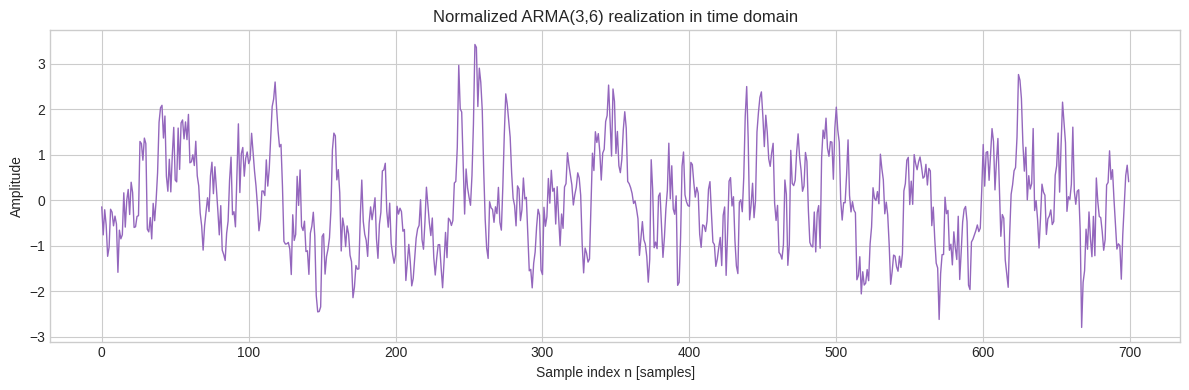

In [80]:
num_samples_arma36: int = 3000  # Output length [samples]
noise_std_arma36: float = 1.0  # Innovation standard deviation
ar_coeffs_arma36: tuple[float, float, float] = (0.55, 0.2625, -0.084375)
ma_coeffs_arma36: tuple[float, float, float, float, float, float] = (0.65, -0.35, 0.15, -0.10, 0.06, -0.03)

x_arma36: NDArray[np.float64] = simulate_arma36(
    num_samples=num_samples_arma36,
    ar_coeffs=ar_coeffs_arma36,
    ma_coeffs=ma_coeffs_arma36,
    noise_std=noise_std_arma36,
    burn_in_samples=600,
    random_seed=999,
)

# Normalize the ARMA(3,6) realization for consistent time-domain and PSD scaling.
x_arma36_norm: NDArray[np.float64] = normalize_process_unit_variance(x_arma36)

print(f"ARMA(3,6) normalized mean: {np.mean(x_arma36_norm):+.3e}")
print(f"ARMA(3,6) normalized var:  {np.var(x_arma36_norm, ddof=0):.4f}")

segment_samples_arma: int = 700
n_arma: NDArray[np.int64] = np.arange(num_samples_arma36, dtype=np.int64)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(
    n_arma[:segment_samples_arma],
    x_arma36_norm[:segment_samples_arma],
    color="tab:purple",
    linewidth=1.0,
)
ax.set_title("Normalized ARMA(3,6) realization in time domain")
ax.set_xlabel("Sample index n [samples]")
ax.set_ylabel("Amplitude")
plt.tight_layout()
plt.show()

# Estimate PSD of normalized ARMA(3,6) realization for the summary figure.
welch_segment_arma36_samples: int = 512
welch_overlap_arma36_samples: int = 256
freq_arma36_psd_hz, psd_arma36_power_per_hz = welch_psd_torch(
    signal_samples=x_arma36_norm,
    sample_rate_hz=sample_rate_hz,
    segment_length_samples=welch_segment_arma36_samples,
    overlap_samples=welch_overlap_arma36_samples,
)
omega_arma36_rad_s, psd_arma36_db = prepare_psd_db_for_omega_band(
    freq_hz=freq_arma36_psd_hz,
    psd_power_per_hz=psd_arma36_power_per_hz,
    omega_max_rad_s=omega_plot_limit_rad_s,
)


## 4) Random Walk process (analytical)

The Random Walk model is:

$$x[n] = x[n-1] + w[n], \quad w[n] \sim \mathcal{N}(0,\sigma_w^2).$$

It can be interpreted as the accumulated sum of white-noise increments, so it is
non-stationary in time domain and concentrates spectral energy at low frequencies.

For direct visual comparison with the other generated processes, we normalize the
realization to zero mean and unit variance before plotting and PSD estimation.

Random Walk normalized mean: +1.516e-16
Random Walk normalized var:  1.0000


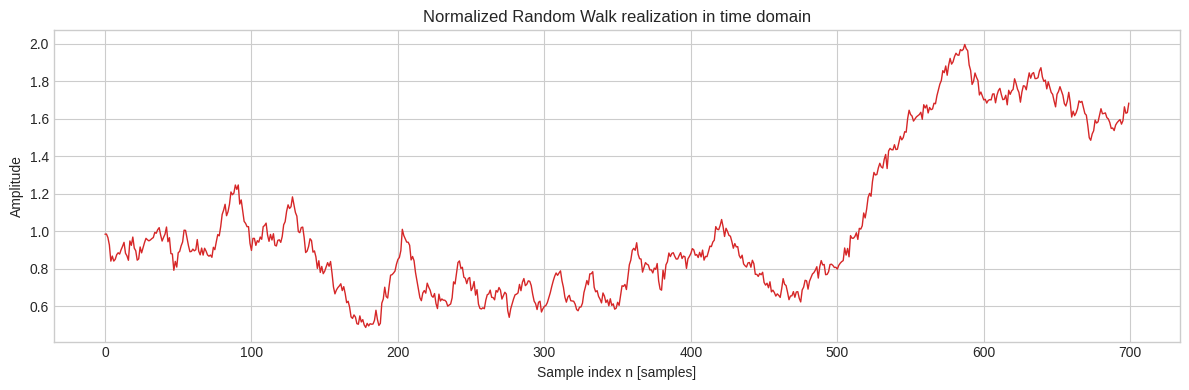

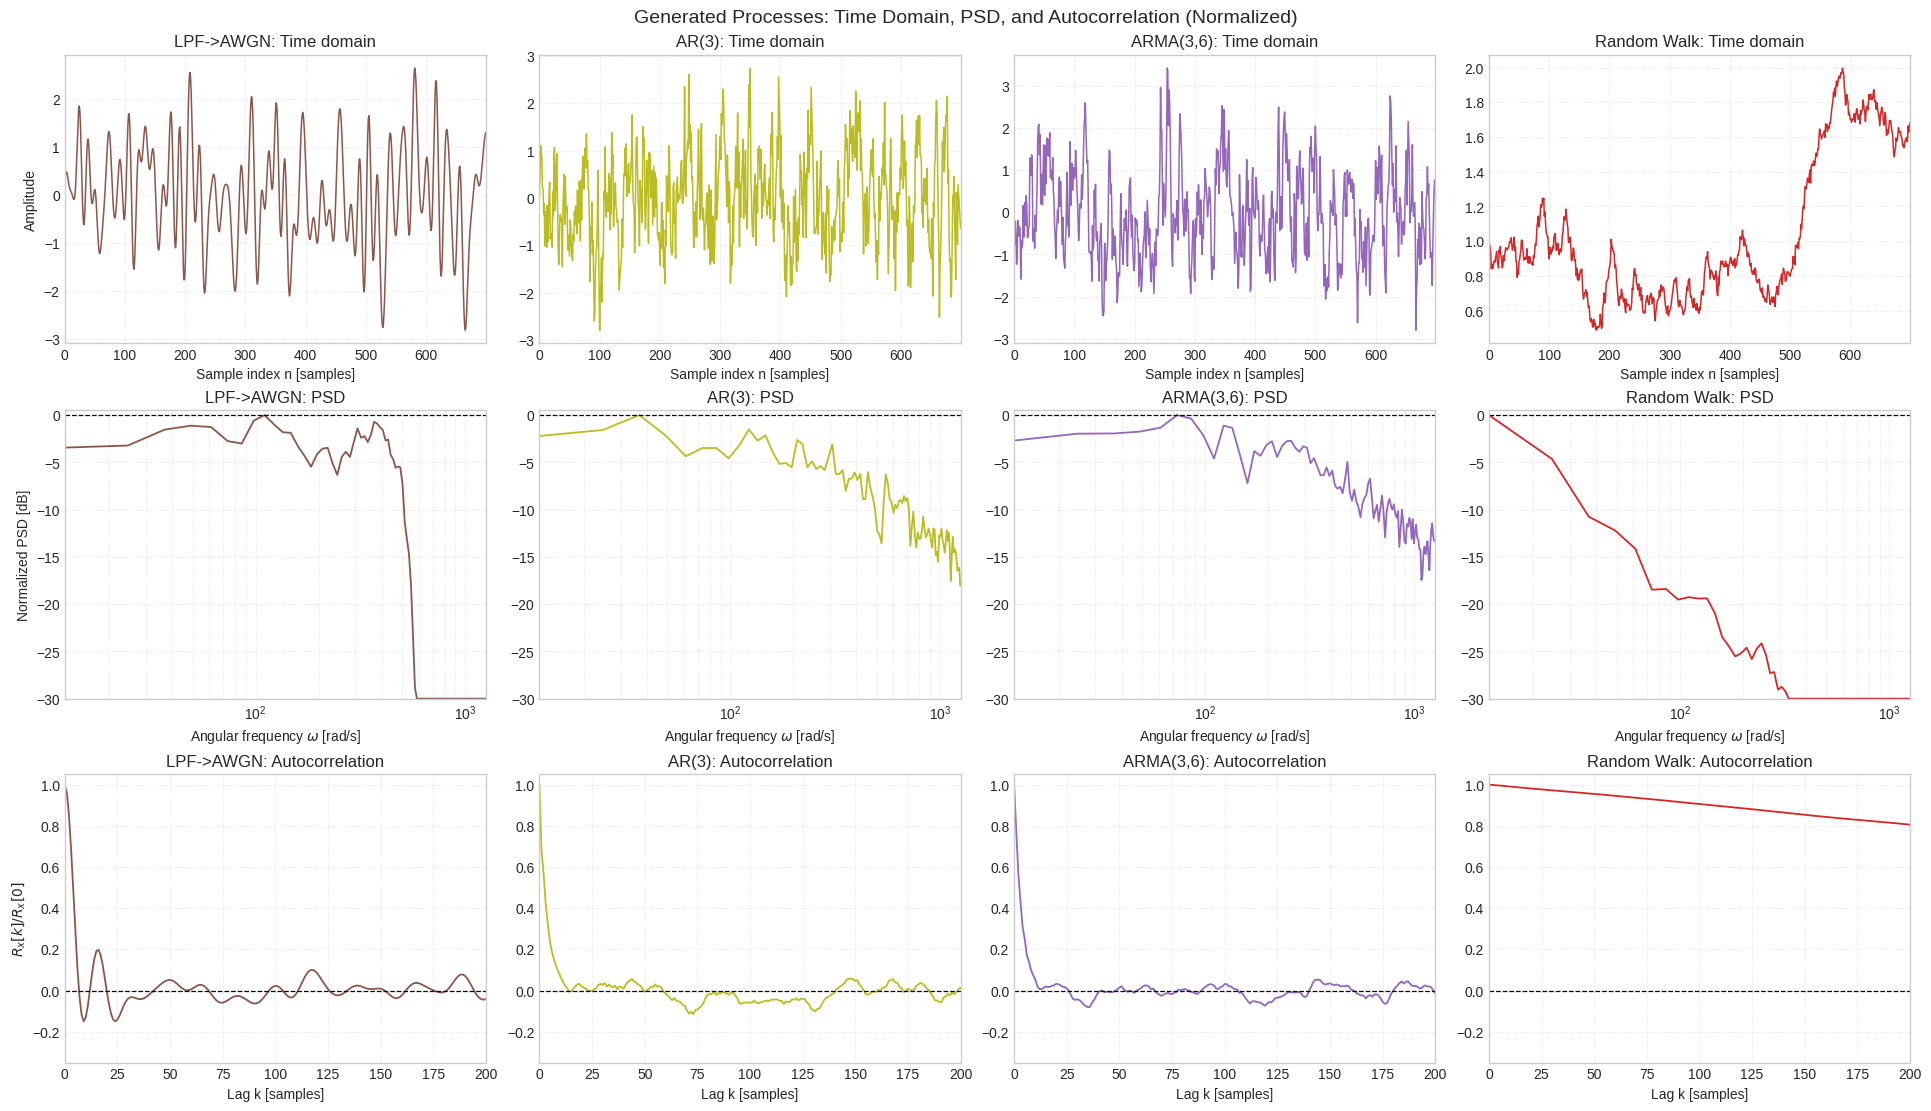

In [81]:
num_samples_random_walk: int = 3000  # Output length [samples]
step_std_random_walk: float = 1.0  # Increment standard deviation

x_random_walk: NDArray[np.float64] = simulate_random_walk(
    num_samples=num_samples_random_walk,
    step_std=step_std_random_walk,
    initial_value=0.0,
    random_seed=2025,
)

# Normalize the random-walk realization for consistent time-domain and PSD scaling.
x_random_walk_norm: NDArray[np.float64] = normalize_process_unit_variance(x_random_walk)

print(f"Random Walk normalized mean: {np.mean(x_random_walk_norm):+.3e}")
print(f"Random Walk normalized var:  {np.var(x_random_walk_norm, ddof=0):.4f}")

segment_samples_rw: int = 700
n_rw: NDArray[np.int64] = np.arange(num_samples_random_walk, dtype=np.int64)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(
    n_rw[:segment_samples_rw],
    x_random_walk_norm[:segment_samples_rw],
    color="tab:red",
    linewidth=1.0,
)
ax.set_title("Normalized Random Walk realization in time domain")
ax.set_xlabel("Sample index n [samples]")
ax.set_ylabel("Amplitude")
plt.tight_layout()
plt.show()

# Estimate PSD of normalized Random Walk realization for the summary figure.
welch_segment_rw_samples: int = 512
welch_overlap_rw_samples: int = 256
freq_rw_psd_hz, psd_rw_power_per_hz = welch_psd_torch(
    signal_samples=x_random_walk_norm,
    sample_rate_hz=sample_rate_hz,
    segment_length_samples=welch_segment_rw_samples,
    overlap_samples=welch_overlap_rw_samples,
)
omega_rw_rad_s, psd_rw_db = prepare_psd_db_for_omega_band(
    freq_hz=freq_rw_psd_hz,
    psd_power_per_hz=psd_rw_power_per_hz,
    omega_max_rad_s=omega_plot_limit_rad_s,
)

# Create one summary figure with time-domain, PSD, and autocorrelation views.
summary_time_segment_samples: int = 700  # Visible time-domain length [samples]
summary_processes = [
    ("LPF->AWGN", omega_lpf_rad_s, psd_lpf_db, y_lpf_norm, "tab:brown"),
    ("AR(3)", omega_ar3_rad_s, psd_ar3_db, x_ar3_norm, "tab:olive"),
    ("ARMA(3,6)", omega_arma36_rad_s, psd_arma36_db, x_arma36_norm, "tab:purple"),
    ("Random Walk", omega_rw_rad_s, psd_rw_db, x_random_walk_norm, "tab:red"),
]

num_summary_processes: int = len(summary_processes)
fig, axes = plt.subplots(
    3,
    num_summary_processes,
    figsize=(4.8 * num_summary_processes, 11),
    constrained_layout=True,
)
if num_summary_processes == 1:
    axes = np.reshape(axes, (3, 1))
for col_idx, (label, omega_rad_s, psd_db, signal_norm, color) in enumerate(summary_processes):
    # Top row: normalized time-domain realizations for direct visual comparison.
    visible_samples: int = min(summary_time_segment_samples, signal_norm.size)
    n_visible: NDArray[np.int64] = np.arange(visible_samples, dtype=np.int64)
    ax_time = axes[0, col_idx]
    ax_time.plot(n_visible, signal_norm[:visible_samples], color=color, linewidth=1.1)
    ax_time.set_title(f"{label}: Time domain")
    ax_time.set_xlim(0, visible_samples - 1)
    ax_time.set_xlabel("Sample index n [samples]")
    ax_time.grid(True, linestyle=":", linewidth=0.6, alpha=0.7)
    if col_idx == 0:
        ax_time.set_ylabel("Amplitude")

    # Middle row: PSD in dB, clipped so only values down to -30 dB are shown.
    psd_clipped_db: NDArray[np.float64] = np.maximum(psd_db, psd_plot_floor_db)
    ax_psd = axes[1, col_idx]
    ax_psd.plot(omega_rad_s, psd_clipped_db, color=color, linewidth=1.3)
    ax_psd.set_xscale("log")
    ax_psd.axhline(0.0, color="black", linestyle="--", linewidth=0.9)
    ax_psd.set_xlim(float(np.min(omega_rad_s)), omega_plot_limit_rad_s)
    ax_psd.set_ylim(psd_plot_floor_db, 0.5)
    ax_psd.set_title(f"{label}: PSD")
    ax_psd.set_xlabel(r"Angular frequency $\omega$ [rad/s]")
    ax_psd.grid(True, which="both", linestyle=":", linewidth=0.6, alpha=0.7)
    if col_idx == 0:
        ax_psd.set_ylabel("Normalized PSD [dB]")

    # Bottom row: corresponding normalized autocorrelation.
    lags_samples, acf_normalized = autocorrelation_normalized_torch(
        signal_samples=signal_norm,
        max_lag_samples=acf_max_lag_samples,
    )
    ax_acf = axes[2, col_idx]
    ax_acf.plot(lags_samples, acf_normalized, color=color, linewidth=1.3)
    ax_acf.axhline(0.0, color="black", linestyle="--", linewidth=0.9)
    ax_acf.set_xlim(0, acf_max_lag_samples)
    ax_acf.set_ylim(-0.35, 1.05)
    ax_acf.set_title(f"{label}: Autocorrelation")
    ax_acf.set_xlabel("Lag k [samples]")
    ax_acf.grid(True, linestyle=":", linewidth=0.6, alpha=0.7)
    if col_idx == 0:
        ax_acf.set_ylabel(r"$R_x[k] / R_x[0]$")

fig.suptitle(
    "Generated Processes: Time Domain, PSD, and Autocorrelation (Normalized)",
    fontsize=14,
)
plt.show()


## 5) Validity of $r_x(\lambda)=\sum_{k=-K}^{K} w_k e^{-\alpha_k\lambda^2}$

We analyze whether
$$
r_x(\lambda)=\sum_{k=-K}^{K} w_k\,e^{-\alpha_k\lambda^2},\qquad w_k\ge 0
$$
can be a valid autocorrelation function (ACF).

**Analytical verification (continuous-lag view):**

1. A function is a valid ACF of a wide-sense stationary process iff it is positive semidefinite (Bochner/Wiener-Khinchin characterization).
2. For each term with $\alpha_k>0$,
   $$
   \mathcal{F}\{e^{-\alpha_k\lambda^2}\}(\omega)
   =\sqrt{\frac{\pi}{\alpha_k}}\,e^{-\omega^2/(4\alpha_k)}\ge 0.
   $$
3. Therefore,
   $$
   S_x(\omega)=\sum_{k=-K}^{K} w_k\sqrt{\frac{\pi}{\alpha_k}}\,e^{-\omega^2/(4\alpha_k)}\ge 0
   $$
   whenever $w_k\ge 0$ and $\alpha_k>0$.
4. Also, $r_x(\lambda)$ is even and $r_x(0)=\sum_k w_k\ge 0$.

**Conclusion:** with finite $K$, nonnegative weights $w_k$, and positive rates $\alpha_k$, the expression is a valid ACF.

The next code cell verifies this numerically (Toeplitz PSD checks + nonnegative spectrum) and empirically (sampled Gaussian process ACF vs theory).


N= 16 | min eigenvalue = +1.617e-01
N= 32 | min eigenvalue = +1.536e-01
N= 64 | min eigenvalue = +1.515e-01
N=128 | min eigenvalue = +1.510e-01
N=256 | min eigenvalue = +1.509e-01
min S_x(omega) on grid = 1.134480e-122
normalized ACF RMSE (empirical vs theory) = 6.080e-03
Verdict: VALID ACF under w_k >= 0 and alpha_k > 0.


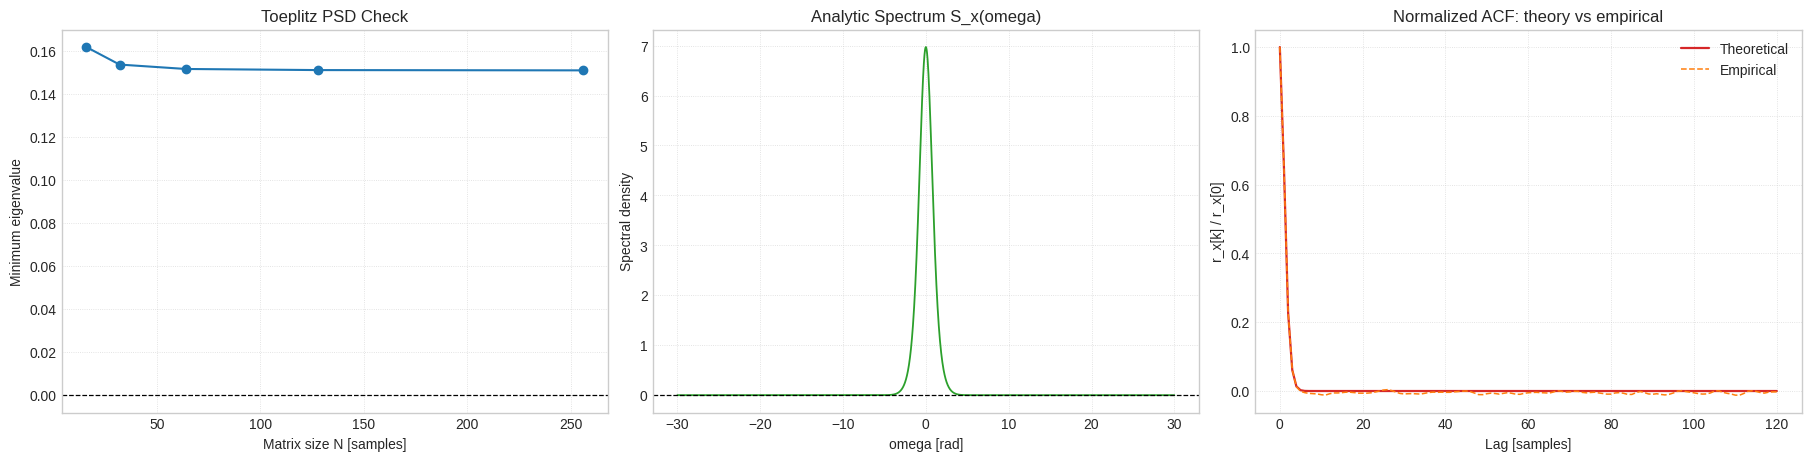

In [82]:
# Parameters for a concrete instance of r_x(lambda) = sum_k w_k exp(-alpha_k lambda^2).
K_mix: int = 2
k_indices: NDArray[np.int64] = np.arange(-K_mix, K_mix + 1, dtype=np.int64)
weights_mix: NDArray[np.float64] = np.array([0.25, 0.55, 0.8, 0.55, 0.25], dtype=np.float64)
alphas_mix: NDArray[np.float64] = np.array([0.18, 0.35, 0.8, 0.35, 0.18], dtype=np.float64)


def gaussian_mixture_acf(
    lags: NDArray[np.float64],  # Lag values lambda [samples or continuous units]
    weights: NDArray[np.float64],  # Mixture coefficients w_k (must be nonnegative)
    alphas: NDArray[np.float64],  # Exponential rates alpha_k (must be positive)
) -> NDArray[np.float64]:  # Candidate autocorrelation values r_x(lambda)
    """Evaluates the Gaussian-mixture candidate autocorrelation function.

    Purpose:
        Compute r_x(lambda) = sum_k w_k exp(-alpha_k * lambda^2) and enforce
        parameter conditions required by the analytical validity argument.

    Parameters:
        lags: Points where the candidate ACF is evaluated.
        weights: Nonnegative coefficients multiplying each Gaussian kernel.
        alphas: Positive rates controlling kernel widths.

    Returns:
        A one-dimensional array with r_x evaluated at each lag.

    Side effects:
        None.
    """
    lag_array: NDArray[np.float64] = np.asarray(lags, dtype=np.float64)
    weight_array: NDArray[np.float64] = np.asarray(weights, dtype=np.float64)
    alpha_array: NDArray[np.float64] = np.asarray(alphas, dtype=np.float64)

    if weight_array.ndim != 1 or alpha_array.ndim != 1:
        raise ValueError("weights and alphas must be one-dimensional.")
    if weight_array.shape != alpha_array.shape:
        raise ValueError("weights and alphas must have the same shape.")
    if np.any(weight_array < 0.0):
        raise ValueError("All weights must satisfy w_k >= 0.")
    if np.any(alpha_array <= 0.0):
        raise ValueError("All alpha_k values must be strictly positive.")

    # Evaluate all kernels in a vectorized way and sum over k.
    lag_sq = lag_array[None, :] ** 2
    kernels = np.exp(-alpha_array[:, None] * lag_sq)
    return np.sum(weight_array[:, None] * kernels, axis=0).astype(np.float64)


def toeplitz_covariance_from_acf(
    num_samples: int,  # Matrix size N [samples]
    weights: NDArray[np.float64],  # Mixture coefficients w_k
    alphas: NDArray[np.float64],  # Exponential rates alpha_k
) -> NDArray[np.float64]:  # Toeplitz covariance matrix C in R^{N x N}
    """Builds a Toeplitz covariance matrix from the candidate ACF.

    Purpose:
        Numerically test positive semidefiniteness by creating C[i,j]=r_x(i-j)
        over integer lags and inspecting its eigenvalues.

    Parameters:
        num_samples: Dimension N of the covariance matrix.
        weights: Nonnegative mixture weights.
        alphas: Positive Gaussian rates.

    Returns:
        A symmetric Toeplitz covariance matrix implied by the candidate ACF.

    Side effects:
        None.
    """
    if num_samples <= 0:
        raise ValueError("num_samples must be positive.")

    # Compute r_x[l] for l = 0, ..., N-1 and index with |i-j| to form Toeplitz C.
    lags_nonnegative: NDArray[np.float64] = np.arange(num_samples, dtype=np.float64)
    acf_nonnegative: NDArray[np.float64] = gaussian_mixture_acf(
        lags=lags_nonnegative,
        weights=weights,
        alphas=alphas,
    )
    lag_indices: NDArray[np.int64] = np.abs(
        np.subtract.outer(np.arange(num_samples), np.arange(num_samples)),
    )
    return acf_nonnegative[lag_indices].astype(np.float64)


def ensemble_biased_acf(
    realizations: NDArray[np.float64],  # Shape (M, N) with M process realizations
    max_lag_samples: int,  # Largest lag index to estimate [samples]
) -> NDArray[np.float64]:  # Ensemble-averaged biased ACF estimate
    """Estimates non-negative-lag ACF using an ensemble-averaged biased estimator.

    Purpose:
        Compare empirical correlation behavior of simulated realizations against
        the theoretical normalized ACF implied by the candidate expression.

    Parameters:
        realizations: Matrix whose rows are process realizations.
        max_lag_samples: Maximum non-negative lag included in the estimate.

    Returns:
        One-dimensional array with ACF estimates for lags 0..max_lag_samples.

    Side effects:
        None.
    """
    x: NDArray[np.float64] = np.asarray(realizations, dtype=np.float64)
    if x.ndim != 2:
        raise ValueError("realizations must be two-dimensional with shape (M, N).")
    num_realizations, num_samples = x.shape
    if num_realizations <= 0 or num_samples <= 1:
        raise ValueError("realizations must contain at least one nontrivial row.")
    if max_lag_samples < 0 or max_lag_samples >= num_samples:
        raise ValueError("max_lag_samples must satisfy 0 <= lag < N.")

    # Remove each realization mean before covariance estimation.
    x_centered: NDArray[np.float64] = x - np.mean(x, axis=1, keepdims=True)
    acf_estimate = np.empty(max_lag_samples + 1, dtype=np.float64)

    # Use the biased estimator (divide by N) for stable lag-to-lag comparison.
    for lag_idx in range(max_lag_samples + 1):
        acf_estimate[lag_idx] = float(
            np.mean(x_centered[:, : num_samples - lag_idx] * x_centered[:, lag_idx:]),
        )
    return acf_estimate


# Numerical check 1: Toeplitz covariance matrices should be positive semidefinite.
matrix_sizes = [16, 32, 64, 128, 256]
min_eigenvalues: list[float] = []
for matrix_size in matrix_sizes:
    covariance_matrix = toeplitz_covariance_from_acf(
        num_samples=matrix_size,
        weights=weights_mix,
        alphas=alphas_mix,
    )
    min_eigenvalue = float(np.min(np.linalg.eigvalsh(covariance_matrix)))
    min_eigenvalues.append(min_eigenvalue)
    print(f"N={matrix_size:3d} | min eigenvalue = {min_eigenvalue:+.3e}")


# Numerical check 2: continuous-lag spectrum from analytic Fourier transform must be nonnegative.
omega_grid_rad = np.linspace(-30.0, 30.0, 2501)
spectral_density = np.sum(
    weights_mix[:, None]
    * np.sqrt(np.pi / alphas_mix)[:, None]
    * np.exp(-(omega_grid_rad[None, :] ** 2) / (4.0 * alphas_mix[:, None])),
    axis=0,
)
min_spectrum = float(np.min(spectral_density))
print(f"min S_x(omega) on grid = {min_spectrum:.6e}")


# Empirical check: sample a Gaussian vector process with this covariance and compare ACF.
num_samples_empirical: int = 512
num_realizations_empirical: int = 300
max_lag_empirical: int = 120

covariance_empirical = toeplitz_covariance_from_acf(
    num_samples=num_samples_empirical,
    weights=weights_mix,
    alphas=alphas_mix,
)

# Add a tiny diagonal jitter for numerical stability in multivariate sampling.
jitter_variance: float = 1e-10
covariance_empirical += jitter_variance * np.eye(num_samples_empirical)

rng_empirical = np.random.default_rng(seed=2026)
realizations_empirical: NDArray[np.float64] = rng_empirical.multivariate_normal(
    mean=np.zeros(num_samples_empirical, dtype=np.float64),
    cov=covariance_empirical,
    size=num_realizations_empirical,
).astype(np.float64)

acf_empirical = ensemble_biased_acf(
    realizations=realizations_empirical,
    max_lag_samples=max_lag_empirical,
)
lags_empirical = np.arange(max_lag_empirical + 1, dtype=np.float64)
acf_theoretical = gaussian_mixture_acf(
    lags=lags_empirical,
    weights=weights_mix,
    alphas=alphas_mix,
)

acf_empirical_normalized = acf_empirical / acf_empirical[0]
acf_theoretical_normalized = acf_theoretical / acf_theoretical[0]
acf_rmse = float(
    np.sqrt(np.mean((acf_empirical_normalized - acf_theoretical_normalized) ** 2)),
)
print(f"normalized ACF RMSE (empirical vs theory) = {acf_rmse:.3e}")


# Report a binary validity verdict using practical numerical tolerances.
eig_tolerance: float = 1e-9
spectrum_tolerance: float = 1e-12
is_psd_toeplitz = all(min_eig >= -eig_tolerance for min_eig in min_eigenvalues)
is_nonnegative_spectrum = bool(min_spectrum >= -spectrum_tolerance)

if is_psd_toeplitz and is_nonnegative_spectrum:
    print("Verdict: VALID ACF under w_k >= 0 and alpha_k > 0.")
else:
    print("Verdict: NOT validated as a valid ACF for these parameters.")


# Visual summary of numerical and empirical checks.
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), constrained_layout=True)

axes[0].plot(matrix_sizes, min_eigenvalues, marker="o", color="tab:blue")
axes[0].axhline(0.0, color="black", linestyle="--", linewidth=0.9)
axes[0].set_title("Toeplitz PSD Check")
axes[0].set_xlabel("Matrix size N [samples]")
axes[0].set_ylabel("Minimum eigenvalue")
axes[0].grid(True, linestyle=":", linewidth=0.6, alpha=0.7)

axes[1].plot(omega_grid_rad, spectral_density, color="tab:green", linewidth=1.3)
axes[1].axhline(0.0, color="black", linestyle="--", linewidth=0.9)
axes[1].set_title("Analytic Spectrum S_x(omega)")
axes[1].set_xlabel("omega [rad]")
axes[1].set_ylabel("Spectral density")
axes[1].grid(True, linestyle=":", linewidth=0.6, alpha=0.7)

axes[2].plot(
    lags_empirical,
    acf_theoretical_normalized,
    color="tab:red",
    linewidth=1.6,
    label="Theoretical",
)
axes[2].plot(
    lags_empirical,
    acf_empirical_normalized,
    color="tab:orange",
    linewidth=1.1,
    linestyle="--",
    label="Empirical",
)
axes[2].set_title("Normalized ACF: theory vs empirical")
axes[2].set_xlabel("Lag [samples]")
axes[2].set_ylabel("r_x[k] / r_x[0]")
axes[2].grid(True, linestyle=":", linewidth=0.6, alpha=0.7)
axes[2].legend()

plt.show()


## 6) AR(3) approximation using $r_x(\lambda)=\sum_{k=-K}^{K} w_k e^{-\alpha_k\lambda^2}$

This section uses **only the AR(3) process** and tries to approximate its normalized autocorrelation with
$$
\hat r_x(\lambda)=\sum_{k=-K}^{K} w_k e^{-\alpha_k\lambda^2},\qquad w_k\ge 0,\ \alpha_k>0.
$$

Fitting strategy:

1. Estimate the empirical normalized AR(3) autocorrelation for nonnegative lags.
2. Optimize \(w_k\) and \(\alpha_k\) under positivity constraints.
   We enforce constraints with a reparameterization:
   - \(w_k=\mathrm{softmax}(\theta_k)\)  (nonnegative and sum to 1),
   - \(\alpha_k=\exp(\phi_k)\) (strictly positive).
3. Minimize mean-squared error between target ACF and modeled ACF.

Important interpretation:
- Because each term is nonnegative, \(\hat r_x(\lambda)\ge 0\) for all \(\lambda\).
- If the AR(3) empirical ACF contains negative lobes, this constrained model cannot match them exactly; it approximates the positive envelope.


restart=00 | RMSE=0.051720
restart=01 | RMSE=0.051758
restart=02 | RMSE=0.051788
restart=03 | RMSE=0.051732
restart=04 | RMSE=0.051700
restart=05 | RMSE=0.051734
restart=06 | RMSE=0.051745
restart=07 | RMSE=0.051734

Best fitted parameters for AR(3) ACF approximation
K = 2, number of terms = 5
term 0: k=-2, w_k=0.016187, alpha_k=1.147442e-04
term 1: k=-1, w_k=0.030433, alpha_k=7.132020e-04
term 2: k=+0, w_k=0.062820, alpha_k=4.557956e-03
term 3: k=+1, w_k=0.184993, alpha_k=2.731044e-02
term 4: k=+2, w_k=0.705568, alpha_k=1.692337e-01
Overall RMSE:        0.051700
Overall MAE:         0.040387
Target min ACF:      -0.115214
Model min ACF:       0.003103
Negative-lag fraction in target ACF: 0.554
RMSE on negative lags only:          0.060592


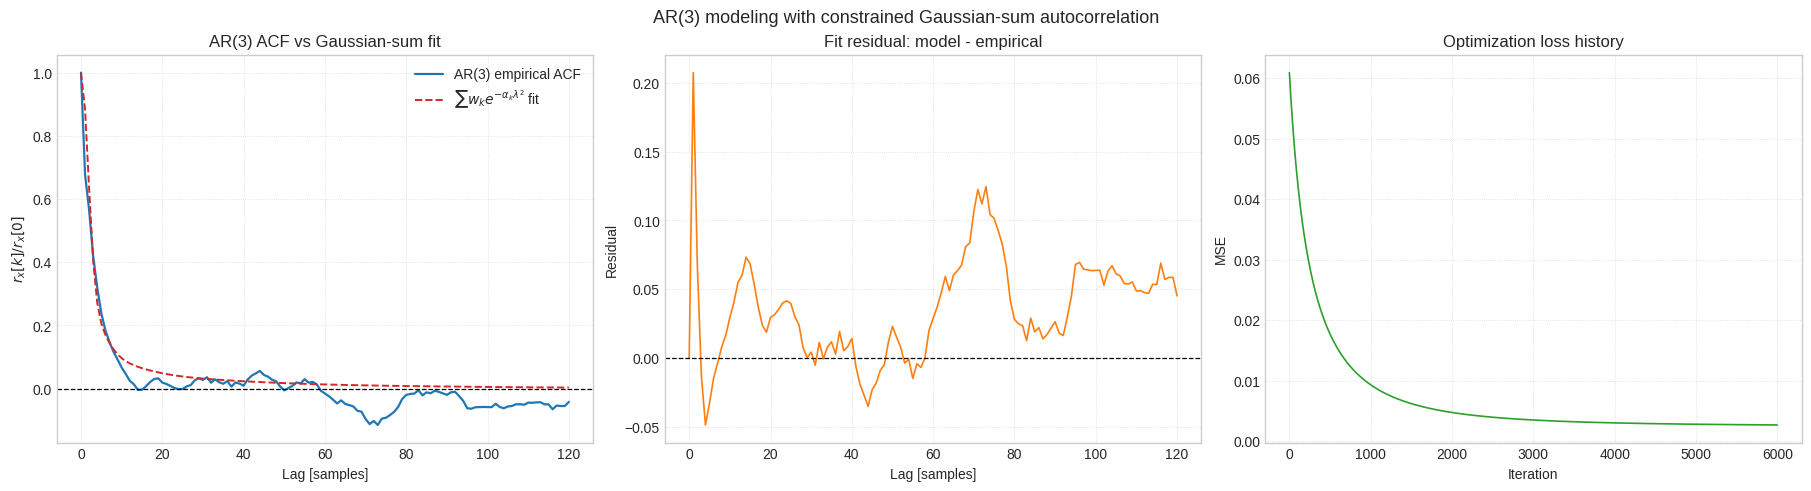

In [83]:
def acf_biased_normalized_numpy(
    signal_samples: NDArray[np.float64],  # Input realization x[n]
    max_lag_samples: int,  # Maximum nonnegative lag [samples]
) -> NDArray[np.float64]:  # Normalized biased ACF for lags 0..max_lag
    """Computes the normalized biased ACF using only NumPy.

    Purpose:
        Estimate the AR(3) target autocorrelation in a deterministic way without
        extra dependencies.

    Parameters:
        signal_samples: One-dimensional realization of the AR(3) process.
        max_lag_samples: Largest nonnegative lag index to estimate.

    Returns:
        A one-dimensional array ``r_hat[k] / r_hat[0]`` for ``k=0..max_lag_samples``.

    Side effects:
        None.
    """
    x: NDArray[np.float64] = np.asarray(signal_samples, dtype=np.float64)
    if x.ndim != 1:
        raise ValueError("signal_samples must be one-dimensional.")
    if max_lag_samples < 0:
        raise ValueError("max_lag_samples must be non-negative.")
    if max_lag_samples >= x.size:
        raise ValueError("max_lag_samples must be smaller than signal length.")

    # Remove the sample mean before covariance estimation.
    x_centered: NDArray[np.float64] = x - float(np.mean(x))
    num_samples: int = x_centered.size
    acf_values: NDArray[np.float64] = np.empty(max_lag_samples + 1, dtype=np.float64)

    # Use the biased estimator (divide by N) for stable lag-to-lag comparison.
    for lag_idx in range(max_lag_samples + 1):
        acf_values[lag_idx] = float(
            np.dot(x_centered[: num_samples - lag_idx], x_centered[lag_idx:])
            / num_samples,
        )

    if abs(acf_values[0]) <= 1e-18:
        raise ValueError("lag-0 autocorrelation is too small to normalize.")
    return (acf_values / acf_values[0]).astype(np.float64)


def _softmax_stable(
    logits: NDArray[np.float64],  # Unconstrained real parameters
) -> NDArray[np.float64]:  # Probability vector summing to one
    """Applies a numerically stable softmax map."""
    shifted_logits: NDArray[np.float64] = logits - float(np.max(logits))
    exp_logits: NDArray[np.float64] = np.exp(shifted_logits)
    return (exp_logits / float(np.sum(exp_logits))).astype(np.float64)


def gaussian_acf_sum_model(
    lags_samples: NDArray[np.float64],  # Lag grid lambda [samples]
    weights: NDArray[np.float64],  # Nonnegative mixture weights that sum to one
    alphas: NDArray[np.float64],  # Positive Gaussian rates
) -> NDArray[np.float64]:  # Modeled ACF values on the lag grid
    """Evaluates r_hat_x(lambda) = sum_k w_k exp(-alpha_k lambda^2).

    Purpose:
        Provide the constrained ACF family used to approximate the AR(3) target ACF.

    Parameters:
        lags_samples: Nonnegative lag grid where the model is evaluated.
        weights: Mixture weights satisfying ``weights >= 0`` and ``sum(weights)=1``.
        alphas: Positive Gaussian rates controlling each component bandwidth.

    Returns:
        Modeled ACF values on ``lags_samples``.

    Side effects:
        None.
    """
    lag_array: NDArray[np.float64] = np.asarray(lags_samples, dtype=np.float64)
    weight_array: NDArray[np.float64] = np.asarray(weights, dtype=np.float64)
    alpha_array: NDArray[np.float64] = np.asarray(alphas, dtype=np.float64)

    if weight_array.ndim != 1 or alpha_array.ndim != 1:
        raise ValueError("weights and alphas must be one-dimensional.")
    if weight_array.shape != alpha_array.shape:
        raise ValueError("weights and alphas must have the same shape.")
    if np.any(weight_array < 0.0):
        raise ValueError("weights must be nonnegative.")
    if np.any(alpha_array <= 0.0):
        raise ValueError("alphas must be strictly positive.")

    # Evaluate basis functions for all lags and combine them linearly.
    lag_sq: NDArray[np.float64] = lag_array[None, :] ** 2
    gaussian_basis: NDArray[np.float64] = np.exp(-alpha_array[:, None] * lag_sq)
    return np.sum(weight_array[:, None] * gaussian_basis, axis=0).astype(np.float64)


def fit_positive_gaussian_acf_mixture(
    target_acf: NDArray[np.float64],  # Target normalized ACF values
    lags_samples: NDArray[np.float64],  # Lag grid associated with target_acf [samples]
    num_terms: int,  # Number of Gaussian terms M = 2K+1
    num_iterations: int = 6000,  # Gradient-descent iterations
    learning_rate_logits: float = 0.08,  # Step size for weight logits
    learning_rate_log_alphas: float = 0.02,  # Step size for log-alpha variables
    random_seed: int = 0,  # Initialization seed
) -> tuple[
    NDArray[np.float64],
    NDArray[np.float64],
    NDArray[np.float64],
    NDArray[np.float64],
]:  # (weights, alphas, fitted_acf, loss_history)
    """Fits the constrained Gaussian-sum ACF model to a target autocorrelation.

    Purpose:
        Estimate nonnegative ``weights`` and positive ``alphas`` that minimize the
        mean-squared error between model and AR(3) empirical ACF.

    Parameters:
        target_acf: Target normalized ACF values over ``lags_samples``.
        lags_samples: Nonnegative lag grid used for fitting.
        num_terms: Number of Gaussian kernels in the sum.
        num_iterations: Number of gradient steps.
        learning_rate_logits: Learning rate for softmax logits (weights).
        learning_rate_log_alphas: Learning rate for log-alpha parameters.
        random_seed: Random seed for deterministic initialization.

    Returns:
        Tuple with fitted ``weights``, fitted ``alphas``, modeled ACF, and loss history.

    Side effects:
        None.
    """
    target_array: NDArray[np.float64] = np.asarray(target_acf, dtype=np.float64)
    lag_array: NDArray[np.float64] = np.asarray(lags_samples, dtype=np.float64)

    if target_array.ndim != 1 or lag_array.ndim != 1:
        raise ValueError("target_acf and lags_samples must be one-dimensional.")
    if target_array.shape != lag_array.shape:
        raise ValueError("target_acf and lags_samples must have the same shape.")
    if num_terms <= 0:
        raise ValueError("num_terms must be positive.")
    if num_iterations <= 0:
        raise ValueError("num_iterations must be positive.")

    # Initialize unconstrained parameters, then map to valid weights/alphas.
    rng = np.random.default_rng(seed=random_seed)
    logits: NDArray[np.float64] = 0.01 * rng.normal(size=num_terms).astype(np.float64)
    log_alphas: NDArray[np.float64] = np.log(np.geomspace(1e-4, 0.15, num_terms)).astype(np.float64)
    lag_sq: NDArray[np.float64] = lag_array**2
    loss_history: NDArray[np.float64] = np.empty(num_iterations, dtype=np.float64)

    for step_idx in range(num_iterations):
        weights = _softmax_stable(logits)
        alphas = np.exp(log_alphas)

        gaussian_basis = np.exp(-alphas[:, None] * lag_sq[None, :])
        fitted_acf = np.sum(weights[:, None] * gaussian_basis, axis=0)

        residual = fitted_acf - target_array
        loss_history[step_idx] = float(np.mean(residual**2))
        grad_fitted = (2.0 / residual.size) * residual

        # Backpropagate through softmax weights.
        grad_weights = gaussian_basis @ grad_fitted
        weighted_grad = float(np.sum(weights * grad_weights))
        grad_logits = weights * (grad_weights - weighted_grad)

        # Backpropagate through alpha = exp(log_alpha).
        grad_alphas = np.sum(
            (weights[:, None] * (-lag_sq[None, :]) * gaussian_basis)
            * grad_fitted[None, :],
            axis=1,
        )
        grad_log_alphas = grad_alphas * alphas

        # Clip gradients for numerical stability before each update.
        grad_logits = np.clip(grad_logits, -5.0, 5.0)
        grad_log_alphas = np.clip(grad_log_alphas, -5.0, 5.0)

        logits -= learning_rate_logits * grad_logits
        log_alphas -= learning_rate_log_alphas * grad_log_alphas
        log_alphas = np.clip(log_alphas, np.log(1e-6), np.log(3.0))

    weights_final = _softmax_stable(logits)
    alphas_final = np.exp(log_alphas)
    fitted_final = gaussian_acf_sum_model(
        lags_samples=lag_array,
        weights=weights_final,
        alphas=alphas_final,
    )
    return (
        weights_final.astype(np.float64),
        alphas_final.astype(np.float64),
        fitted_final.astype(np.float64),
        loss_history.astype(np.float64),
    )


# Ensure AR(3) data from section 2 exists before fitting.
if "x_ar3_norm" not in globals():
    raise RuntimeError(
        "x_ar3_norm not found. Run the AR(3) simulation cell before this section.",
    )

# Build the target AR(3) normalized ACF over a finite lag window.
max_lag_fit_samples: int = 120
lags_fit_samples: NDArray[np.float64] = np.arange(max_lag_fit_samples + 1, dtype=np.float64)
target_acf_ar3: NDArray[np.float64] = acf_biased_normalized_numpy(
    signal_samples=x_ar3_norm,
    max_lag_samples=max_lag_fit_samples,
)

# Fit M = 2K+1 Gaussian terms (here M=5 => K=2) with several random restarts.
num_terms_gaussian: int = 5
num_restarts: int = 8
best_result: dict[str, NDArray[np.float64] | float] | None = None

for restart_seed in range(num_restarts):
    weights_fit, alphas_fit, fitted_acf, loss_history = fit_positive_gaussian_acf_mixture(
        target_acf=target_acf_ar3,
        lags_samples=lags_fit_samples,
        num_terms=num_terms_gaussian,
        num_iterations=6000,
        learning_rate_logits=0.08,
        learning_rate_log_alphas=0.02,
        random_seed=restart_seed,
    )
    rmse_restart = float(np.sqrt(np.mean((fitted_acf - target_acf_ar3) ** 2)))
    print(f"restart={restart_seed:02d} | RMSE={rmse_restart:.6f}")

    if best_result is None or rmse_restart < float(best_result["rmse"]):
        best_result = {
            "rmse": rmse_restart,
            "weights": weights_fit,
            "alphas": alphas_fit,
            "fitted_acf": fitted_acf,
            "loss_history": loss_history,
        }

if best_result is None:
    raise RuntimeError("Fitting failed to produce a valid solution.")

best_rmse = float(best_result["rmse"])
best_weights = np.asarray(best_result["weights"], dtype=np.float64)
best_alphas = np.asarray(best_result["alphas"], dtype=np.float64)
best_fitted_acf = np.asarray(best_result["fitted_acf"], dtype=np.float64)
best_loss_history = np.asarray(best_result["loss_history"], dtype=np.float64)

# Compute summary diagnostics, including mismatch over negative ACF lags.
acf_residual: NDArray[np.float64] = best_fitted_acf - target_acf_ar3
mae_fit: float = float(np.mean(np.abs(acf_residual)))
negative_lag_mask: NDArray[np.bool_] = target_acf_ar3 < 0.0
negative_fraction: float = float(np.mean(negative_lag_mask.astype(np.float64)))

if np.any(negative_lag_mask):
    rmse_negative: float = float(
        np.sqrt(np.mean((acf_residual[negative_lag_mask]) ** 2)),
    )
else:
    rmse_negative = 0.0

K_fit: int = (num_terms_gaussian - 1) // 2
k_indices_fit: NDArray[np.int64] = np.arange(-K_fit, K_fit + 1, dtype=np.int64)

print("\nBest fitted parameters for AR(3) ACF approximation")
print(f"K = {K_fit}, number of terms = {num_terms_gaussian}")
for idx, (k_idx, weight_val, alpha_val) in enumerate(
    zip(k_indices_fit, best_weights, best_alphas),
):
    print(f"term {idx}: k={k_idx:+d}, w_k={weight_val:.6f}, alpha_k={alpha_val:.6e}")

print(f"Overall RMSE:        {best_rmse:.6f}")
print(f"Overall MAE:         {mae_fit:.6f}")
print(f"Target min ACF:      {float(np.min(target_acf_ar3)):.6f}")
print(f"Model min ACF:       {float(np.min(best_fitted_acf)):.6f}")
print(f"Negative-lag fraction in target ACF: {negative_fraction:.3f}")
print(f"RMSE on negative lags only:          {rmse_negative:.6f}")

# Plot fit quality, residual structure, and optimizer convergence.
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8), constrained_layout=True)

axes[0].plot(
    lags_fit_samples,
    target_acf_ar3,
    color="tab:blue",
    linewidth=1.6,
    label="AR(3) empirical ACF",
)
axes[0].plot(
    lags_fit_samples,
    best_fitted_acf,
    color="tab:red",
    linewidth=1.4,
    linestyle="--",
    label=r"$\sum w_k e^{-\alpha_k \lambda^2}$ fit",
)
axes[0].axhline(0.0, color="black", linestyle="--", linewidth=0.9)
axes[0].set_title("AR(3) ACF vs Gaussian-sum fit")
axes[0].set_xlabel("Lag [samples]")
axes[0].set_ylabel(r"$r_x[k] / r_x[0]$")
axes[0].grid(True, linestyle=":", linewidth=0.6, alpha=0.7)
axes[0].legend()

axes[1].plot(lags_fit_samples, acf_residual, color="tab:orange", linewidth=1.2)
axes[1].axhline(0.0, color="black", linestyle="--", linewidth=0.9)
axes[1].set_title("Fit residual: model - empirical")
axes[1].set_xlabel("Lag [samples]")
axes[1].set_ylabel("Residual")
axes[1].grid(True, linestyle=":", linewidth=0.6, alpha=0.7)

axes[2].plot(best_loss_history, color="tab:green", linewidth=1.2)
axes[2].set_title("Optimization loss history")
axes[2].set_xlabel("Iteration")
axes[2].set_ylabel("MSE")
axes[2].grid(True, linestyle=":", linewidth=0.6, alpha=0.7)

fig.suptitle("AR(3) modeling with constrained Gaussian-sum autocorrelation", fontsize=13)
plt.show()


AR(3) ACF comparison RMSE: 0.047505
AR(3) PSD comparison RMSE (dB, clipped): 10.460233


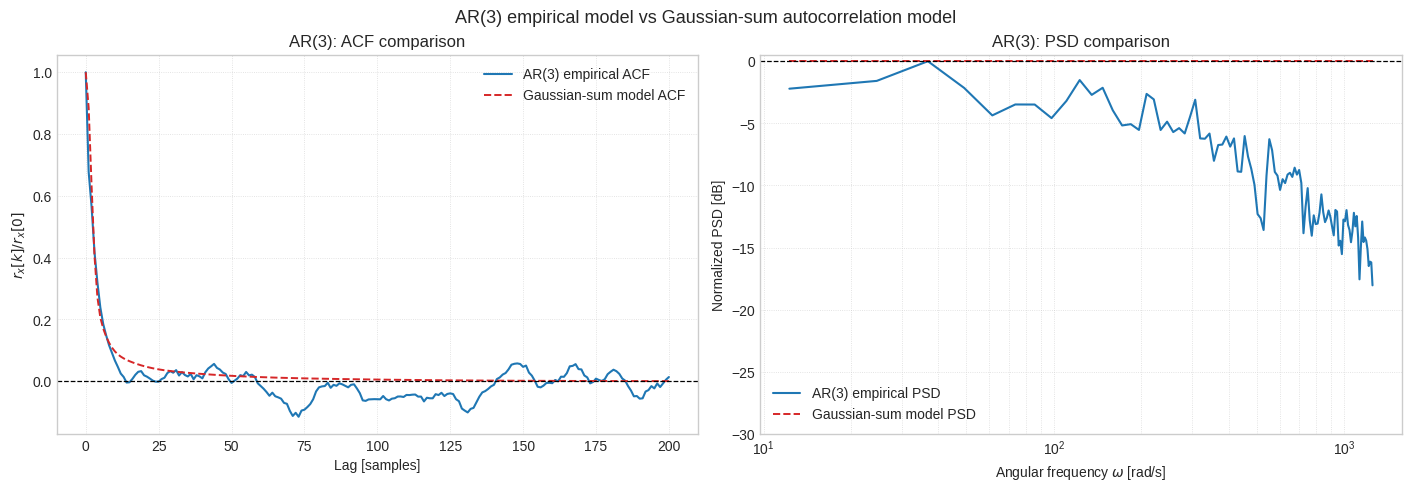

In [84]:
# Compare AR(3) empirical model and Gaussian-sum ACF model in both ACF and PSD.
required_vars = ["x_ar3_norm", "best_weights", "best_alphas"]
missing_vars = [var_name for var_name in required_vars if var_name not in globals()]
if missing_vars:
    raise RuntimeError(
        "Missing variables for AR(3) comparison: "
        + ", ".join(missing_vars)
        + ". Run sections 2 and 5 first.",
    )

# Build ACF comparison over a shared lag grid.
max_lag_compare_samples: int = int(globals().get("acf_max_lag_samples", 200))
lags_compare_samples: NDArray[np.float64] = np.arange(max_lag_compare_samples + 1, dtype=np.float64)

if "acf_biased_normalized_numpy" in globals():
    acf_ar3_compare: NDArray[np.float64] = acf_biased_normalized_numpy(
        signal_samples=np.asarray(x_ar3_norm, dtype=np.float64),
        max_lag_samples=max_lag_compare_samples,
    )
else:
    x_ar3_centered = np.asarray(x_ar3_norm, dtype=np.float64) - float(np.mean(x_ar3_norm))
    num_samples_ar3_compare: int = int(x_ar3_centered.size)
    acf_ar3_compare = np.empty(max_lag_compare_samples + 1, dtype=np.float64)
    for lag_idx in range(max_lag_compare_samples + 1):
        acf_ar3_compare[lag_idx] = float(
            np.dot(x_ar3_centered[: num_samples_ar3_compare - lag_idx], x_ar3_centered[lag_idx:])
            / num_samples_ar3_compare,
        )
    acf_ar3_compare /= acf_ar3_compare[0]

weights_compare: NDArray[np.float64] = np.asarray(best_weights, dtype=np.float64)
alphas_compare: NDArray[np.float64] = np.asarray(best_alphas, dtype=np.float64)

if "gaussian_acf_sum_model" in globals():
    acf_model_compare: NDArray[np.float64] = gaussian_acf_sum_model(
        lags_samples=lags_compare_samples,
        weights=weights_compare,
        alphas=alphas_compare,
    )
else:
    lag_sq_compare = lags_compare_samples[None, :] ** 2
    acf_model_compare = np.sum(
        weights_compare[:, None] * np.exp(-alphas_compare[:, None] * lag_sq_compare),
        axis=0,
    ).astype(np.float64)

acf_model_compare /= acf_model_compare[0]
acf_compare_rmse: float = float(np.sqrt(np.mean((acf_ar3_compare - acf_model_compare) ** 2)))

# Build PSD comparison on a shared positive angular-frequency grid.
if "omega_ar3_rad_s" in globals() and "psd_ar3_db" in globals():
    omega_compare_rad_s: NDArray[np.float64] = np.asarray(omega_ar3_rad_s, dtype=np.float64)
    psd_ar3_compare_db: NDArray[np.float64] = np.asarray(psd_ar3_db, dtype=np.float64)
else:
    sample_rate_compare_hz: float = float(globals().get("sample_rate_hz", 1.0))
    nfft_compare: int = 4096
    x_psd = np.asarray(x_ar3_norm, dtype=np.float64) - float(np.mean(x_ar3_norm))
    spectrum_compare = np.fft.rfft(x_psd, n=nfft_compare)
    psd_compare_linear = (np.abs(spectrum_compare) ** 2) / nfft_compare
    freq_compare_hz = np.fft.rfftfreq(nfft_compare, d=1.0 / sample_rate_compare_hz)
    omega_compare_rad_s = 2.0 * np.pi * freq_compare_hz

    omega_limit_rad_s: float = float(globals().get("omega_plot_limit_rad_s", float(np.max(omega_compare_rad_s))))
    positive_mask = (omega_compare_rad_s > 0.0) & (omega_compare_rad_s <= omega_limit_rad_s)
    omega_compare_rad_s = omega_compare_rad_s[positive_mask]
    psd_ar3_compare_linear = np.maximum(psd_compare_linear[positive_mask], 1e-18)
    psd_ar3_compare_db = 10.0 * np.log10(psd_ar3_compare_linear)
    psd_ar3_compare_db -= float(np.max(psd_ar3_compare_db))

omega_compare_rad_s = np.asarray(omega_compare_rad_s, dtype=np.float64)
positive_omega_mask = omega_compare_rad_s > 0.0
omega_compare_rad_s = omega_compare_rad_s[positive_omega_mask]
psd_ar3_compare_db = np.asarray(psd_ar3_compare_db, dtype=np.float64)[positive_omega_mask]

psd_model_linear = np.sum(
    weights_compare[:, None]
    * np.sqrt(np.pi / alphas_compare)[:, None]
    * np.exp(-(omega_compare_rad_s[None, :] ** 2) / (4.0 * alphas_compare[:, None])),
    axis=0,
).astype(np.float64)
psd_model_linear = np.maximum(psd_model_linear, 1e-18)
psd_model_compare_db = 10.0 * np.log10(psd_model_linear)
psd_model_compare_db -= float(np.max(psd_model_compare_db))

psd_compare_floor_db: float = float(globals().get("psd_plot_floor_db", -40.0))
psd_ar3_clipped_db = np.maximum(psd_ar3_compare_db, psd_compare_floor_db)
psd_model_clipped_db = np.maximum(psd_model_compare_db, psd_compare_floor_db)
psd_compare_rmse_db: float = float(np.sqrt(np.mean((psd_ar3_clipped_db - psd_model_clipped_db) ** 2)))

print(f"AR(3) ACF comparison RMSE: {acf_compare_rmse:.6f}")
print(f"AR(3) PSD comparison RMSE (dB, clipped): {psd_compare_rmse_db:.6f}")

# Plot side-by-side ACF and PSD comparisons for both AR(3) models.
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), constrained_layout=True)

axes[0].plot(
    lags_compare_samples,
    acf_ar3_compare,
    color="tab:blue",
    linewidth=1.5,
    label="AR(3) empirical ACF",
)
axes[0].plot(
    lags_compare_samples,
    acf_model_compare,
    color="tab:red",
    linewidth=1.4,
    linestyle="--",
    label=r"Gaussian-sum model ACF",
)
axes[0].axhline(0.0, color="black", linestyle="--", linewidth=0.9)
axes[0].set_title("AR(3): ACF comparison")
axes[0].set_xlabel("Lag [samples]")
axes[0].set_ylabel(r"$r_x[k] / r_x[0]$")
axes[0].grid(True, linestyle=":", linewidth=0.6, alpha=0.7)
axes[0].legend()

axes[1].plot(
    omega_compare_rad_s,
    psd_ar3_clipped_db,
    color="tab:blue",
    linewidth=1.5,
    label="AR(3) empirical PSD",
)
axes[1].plot(
    omega_compare_rad_s,
    psd_model_clipped_db,
    color="tab:red",
    linewidth=1.4,
    linestyle="--",
    label="Gaussian-sum model PSD",
)
axes[1].set_xscale("log")
axes[1].axhline(0.0, color="black", linestyle="--", linewidth=0.9)
axes[1].set_title("AR(3): PSD comparison")
axes[1].set_xlabel(r"Angular frequency $\omega$ [rad/s]")
axes[1].set_ylabel("Normalized PSD [dB]")
axes[1].set_ylim(psd_compare_floor_db, 0.5)
axes[1].grid(True, which="both", linestyle=":", linewidth=0.6, alpha=0.7)
axes[1].legend()

fig.suptitle("AR(3) empirical model vs Gaussian-sum autocorrelation model", fontsize=13)
plt.show()


epsilon not defined. Using default epsilon=0.0800
Sweeping K values from 0 to 30 with step 1 (31 total values).

K-sweep summary (best per K)
K= 0 | max|error|=0.649218 | RMSE=0.191115
K= 1 | max|error|=0.202884 | RMSE=0.058386
K= 2 | max|error|=0.224701 | RMSE=0.062340
K= 3 | max|error|=0.241093 | RMSE=0.072064
K= 4 | max|error|=0.254164 | RMSE=0.083336
K= 5 | max|error|=0.262436 | RMSE=0.093339
K= 6 | max|error|=0.268797 | RMSE=0.102737
K= 7 | max|error|=0.276567 | RMSE=0.110789
K= 8 | max|error|=0.295668 | RMSE=0.117847
K= 9 | max|error|=0.309738 | RMSE=0.124153
K=10 | max|error|=0.321220 | RMSE=0.129483
K=11 | max|error|=0.331389 | RMSE=0.134648
K=12 | max|error|=0.339687 | RMSE=0.138878
K=13 | max|error|=0.348498 | RMSE=0.143303
K=14 | max|error|=0.358342 | RMSE=0.147175
K=15 | max|error|=0.364535 | RMSE=0.150140
K=16 | max|error|=0.372084 | RMSE=0.153243
K=17 | max|error|=0.379621 | RMSE=0.156509
K=18 | max|error|=0.385184 | RMSE=0.158760
K=19 | max|error|=0.390623 | RMSE=0.16135

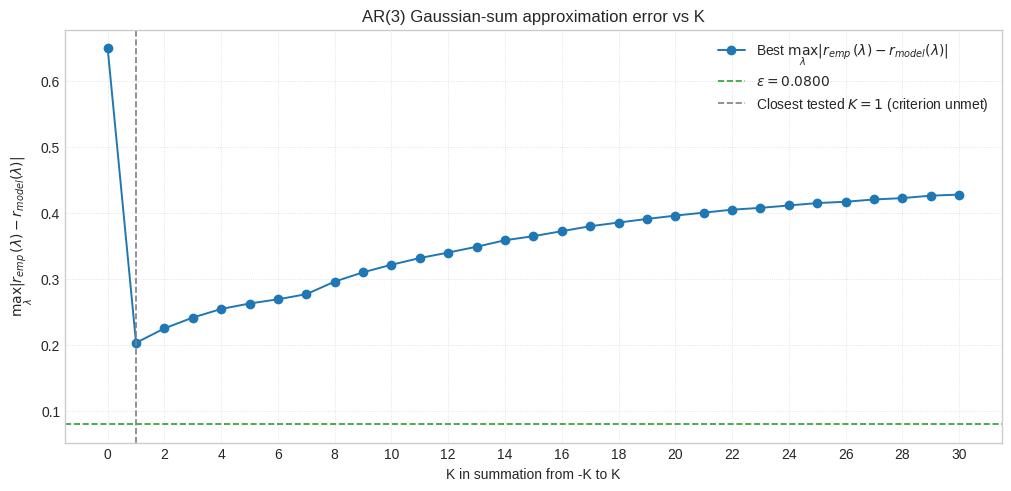

In [85]:
# Search K values for the Gaussian-sum model and mark the smallest K satisfying |error| <= epsilon.
required_names = [
    "x_ar3_norm",
    "acf_biased_normalized_numpy",
    "fit_positive_gaussian_acf_mixture",
]
missing_names = [name for name in required_names if name not in globals()]
if missing_names:
    raise RuntimeError(
        "Missing prerequisites: "
        + ", ".join(missing_names)
        + ". Run section 5 before this cell.",
    )


def sweep_k_for_epsilon_criterion(
    target_acf: NDArray[np.float64],  # Empirical normalized AR(3) ACF
    lags_samples: NDArray[np.float64],  # Lag grid associated with target ACF [samples]
    k_values: NDArray[np.int64],  # Candidate K values in sum from -K to K
    epsilon_threshold: float,  # Allowed maximum absolute error
    num_restarts: int = 4,  # Restarts for each K to reduce local-minimum bias
    num_iterations: int = 2500,  # Optimization steps per restart
) -> tuple[NDArray[np.float64], NDArray[np.float64], int | None]:
    """Evaluates Gaussian-sum fit quality for multiple K values.

    Purpose:
        For each K, fit ``sum_{k=-K}^{K} w_k exp(-alpha_k lambda^2)`` to the AR(3)
        empirical ACF and measure approximation errors. Then identify the smallest K
        whose maximum absolute error is below ``epsilon_threshold``.

    Parameters:
        target_acf: Empirical normalized AR(3) ACF values.
        lags_samples: Lag grid where ``target_acf`` is defined.
        k_values: Integer candidate values for K.
        epsilon_threshold: Error tolerance for
            ``max|target - model| <= epsilon_threshold``.
        num_restarts: Number of random initializations per K.
        num_iterations: Optimization iterations per initialization.

    Returns:
        Tuple ``(max_abs_errors, rmse_errors, selected_k)`` where:
        - ``max_abs_errors[i]`` is best max absolute error for ``k_values[i]``.
        - ``rmse_errors[i]`` is best RMSE for ``k_values[i]``.
        - ``selected_k`` is the first K satisfying the epsilon criterion, or ``None``.

    Side effects:
        None.
    """
    target_array: NDArray[np.float64] = np.asarray(target_acf, dtype=np.float64)
    lag_array: NDArray[np.float64] = np.asarray(lags_samples, dtype=np.float64)
    k_array: NDArray[np.int64] = np.asarray(k_values, dtype=np.int64)

    if target_array.ndim != 1 or lag_array.ndim != 1:
        raise ValueError("target_acf and lags_samples must be one-dimensional.")
    if target_array.shape != lag_array.shape:
        raise ValueError("target_acf and lags_samples must have the same shape.")
    if epsilon_threshold <= 0.0:
        raise ValueError("epsilon_threshold must be positive.")
    if np.any(k_array < 0):
        raise ValueError("All K values must be non-negative.")
    if num_restarts <= 0 or num_iterations <= 0:
        raise ValueError("num_restarts and num_iterations must be positive.")

    max_abs_errors: NDArray[np.float64] = np.empty(k_array.size, dtype=np.float64)
    rmse_errors: NDArray[np.float64] = np.empty(k_array.size, dtype=np.float64)

    # Fit each K model with multiple restarts and keep the best absolute-error solution.
    for idx, k_value in enumerate(k_array):
        num_terms: int = int(2 * k_value + 1)
        best_max_abs_error: float = np.inf
        best_rmse_error: float = np.inf

        for restart_idx in range(num_restarts):
            restart_seed: int = int(1000 * k_value + restart_idx)
            _, _, fitted_acf, _ = fit_positive_gaussian_acf_mixture(
                target_acf=target_array,
                lags_samples=lag_array,
                num_terms=num_terms,
                num_iterations=num_iterations,
                learning_rate_logits=0.08,
                learning_rate_log_alphas=0.02,
                random_seed=restart_seed,
            )

            residual: NDArray[np.float64] = fitted_acf - target_array
            max_abs_error: float = float(np.max(np.abs(residual)))
            rmse_error: float = float(np.sqrt(np.mean(residual**2)))

            if max_abs_error < best_max_abs_error:
                best_max_abs_error = max_abs_error
                best_rmse_error = rmse_error

        max_abs_errors[idx] = best_max_abs_error
        rmse_errors[idx] = best_rmse_error

    # Select the smallest K that satisfies max absolute error <= epsilon.
    valid_mask: NDArray[np.bool_] = max_abs_errors <= epsilon_threshold
    if np.any(valid_mask):
        selected_k: int | None = int(k_array[np.argmax(valid_mask)])
    else:
        selected_k = None

    return max_abs_errors, rmse_errors, selected_k


# Use the same AR(3) target ACF grid as section 5 when available.
max_lag_search_samples: int = int(globals().get("max_lag_fit_samples", 120))
lags_search_samples: NDArray[np.float64] = np.arange(max_lag_search_samples + 1, dtype=np.float64)

target_acf_search: NDArray[np.float64] = acf_biased_normalized_numpy(
    signal_samples=np.asarray(x_ar3_norm, dtype=np.float64),
    max_lag_samples=max_lag_search_samples,
)

# Allow user-provided epsilon; otherwise, use a conservative default.
if "epsilon" in globals():
    epsilon_threshold: float = float(epsilon)
else:
    epsilon_threshold = 0.08
    print(f"epsilon not defined. Using default epsilon={epsilon_threshold:.4f}")

# Sweep a wider K range; override with k_max_search / k_step_search if desired.
k_max_search: int = int(globals().get("k_max_search", 30))
k_step_search: int = int(globals().get("k_step_search", 1))
if k_max_search < 0:
    raise ValueError("k_max_search must be non-negative.")
if k_step_search <= 0:
    raise ValueError("k_step_search must be positive.")

k_values_search: NDArray[np.int64] = np.arange(
    0,
    k_max_search + 1,
    k_step_search,
    dtype=np.int64,
)
print(
    f"Sweeping K values from 0 to {k_max_search} with step {k_step_search} "
    f"({k_values_search.size} total values).",
)

max_abs_errors_k, rmse_errors_k, selected_k_value = sweep_k_for_epsilon_criterion(
    target_acf=target_acf_search,
    lags_samples=lags_search_samples,
    k_values=k_values_search,
    epsilon_threshold=epsilon_threshold,
    num_restarts=4,
    num_iterations=2500,
)

print("\nK-sweep summary (best per K)")
for k_value, max_abs_error, rmse_error in zip(k_values_search, max_abs_errors_k, rmse_errors_k):
    print(f"K={int(k_value):2d} | max|error|={max_abs_error:.6f} | RMSE={rmse_error:.6f}")

if selected_k_value is None:
    closest_k_value: int = int(k_values_search[np.argmin(max_abs_errors_k)])
    print(
        "No tested K satisfies max|Empirical - Gaussian-sum| <= epsilon "
        f"for epsilon={epsilon_threshold:.6f}. Using closest tested K={closest_k_value} for reference.",
    )
else:
    print(
        f"Selected K={selected_k_value} satisfies max|Empirical - Gaussian-sum| "
        f"<= {epsilon_threshold:.6f}.",
    )

# Plot max absolute error vs K, epsilon threshold, and selected K vertical marker.
fig, ax = plt.subplots(figsize=(10, 4.8), constrained_layout=True)
ax.plot(
    k_values_search,
    max_abs_errors_k,
    marker="o",
    linewidth=1.4,
    color="tab:blue",
    label=r"Best $\max_\lambda |r_{emp}(\lambda)-r_{model}(\lambda)|$",
)
ax.axhline(
    epsilon_threshold,
    color="tab:green",
    linestyle="--",
    linewidth=1.2,
    label=fr"$\epsilon={epsilon_threshold:.4f}$",
)

if selected_k_value is not None:
    k_marker_value: int = selected_k_value
    k_marker_label: str = fr"Selected $K={selected_k_value}$"
    k_marker_color: str = "tab:red"
else:
    k_marker_value = int(k_values_search[np.argmin(max_abs_errors_k)])
    k_marker_label = fr"Closest tested $K={k_marker_value}$ (criterion unmet)"
    k_marker_color = "tab:gray"

ax.axvline(
    k_marker_value,
    color=k_marker_color,
    linestyle="--",
    linewidth=1.2,
    label=k_marker_label,
)

ax.set_title("AR(3) Gaussian-sum approximation error vs K")
ax.set_xlabel("K in summation from -K to K")
ax.set_ylabel(r"$\max_\lambda |r_{emp}(\lambda)-r_{model}(\lambda)|$")
# Limit tick density for readability when sweeping many K values.
max_tick_count: int = 20
if k_values_search.size <= max_tick_count:
    ax.set_xticks(k_values_search)
else:
    tick_stride: int = int(np.ceil(k_values_search.size / max_tick_count))
    ax.set_xticks(k_values_search[::tick_stride])
ax.grid(True, linestyle=":", linewidth=0.6, alpha=0.7)
ax.legend()
plt.show()


restart=00 | RMSE=0.053872 | max|error|=0.199008
restart=01 | RMSE=0.053859 | max|error|=0.198990
restart=02 | RMSE=0.053872 | max|error|=0.199004
restart=03 | RMSE=0.053887 | max|error|=0.199025
restart=04 | RMSE=0.053898 | max|error|=0.199035
restart=05 | RMSE=0.053869 | max|error|=0.199009
restart=06 | RMSE=0.053891 | max|error|=0.199028
restart=07 | RMSE=0.053895 | max|error|=0.199031

Best K=1 parameters
term 0: k=-1, w_k=0.022299, alpha_k=1.205123e-04
term 1: k=+0, w_k=0.118363, alpha_k=4.642940e-03
term 2: k=+1, w_k=0.859338, alpha_k=1.545933e-01
K=1 ACF RMSE:       0.053859
K=1 ACF max|error|: 0.198990
K=1 PSD RMSE (dB, clipped): 10.460233


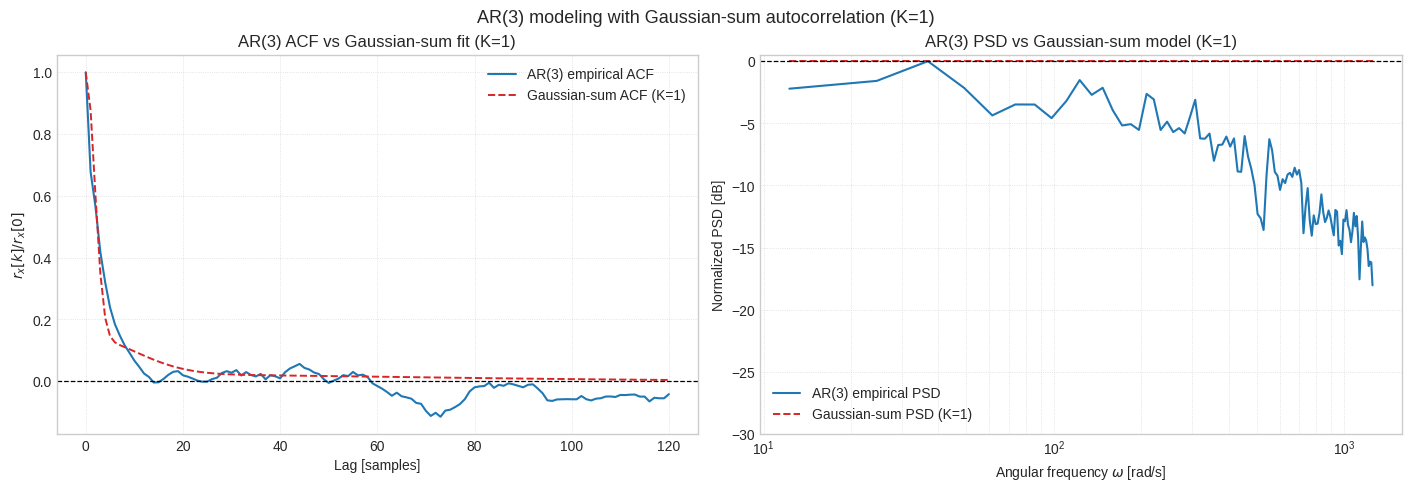

In [86]:
# Plot the AR(3) Gaussian-sum approximation specifically for K=1.
required_names = [
    "x_ar3_norm",
    "acf_biased_normalized_numpy",
    "fit_positive_gaussian_acf_mixture",
]
missing_names = [name for name in required_names if name not in globals()]
if missing_names:
    raise RuntimeError(
        "Missing prerequisites: "
        + ", ".join(missing_names)
        + ". Run section 5 before this cell.",
    )

k_visualize: int = 1
num_terms_visualize: int = int(2 * k_visualize + 1)
max_lag_visualize_samples: int = int(globals().get("max_lag_fit_samples", 120))
lags_visualize_samples: NDArray[np.float64] = np.arange(max_lag_visualize_samples + 1, dtype=np.float64)

target_acf_visualize: NDArray[np.float64] = acf_biased_normalized_numpy(
    signal_samples=np.asarray(x_ar3_norm, dtype=np.float64),
    max_lag_samples=max_lag_visualize_samples,
)

# Fit K=1 with multiple restarts and keep the lowest-RMSE solution.
num_restarts_visualize: int = 8
best_result_visualize: dict[str, NDArray[np.float64] | float] | None = None

for restart_idx in range(num_restarts_visualize):
    weights_fit, alphas_fit, fitted_acf, _ = fit_positive_gaussian_acf_mixture(
        target_acf=target_acf_visualize,
        lags_samples=lags_visualize_samples,
        num_terms=num_terms_visualize,
        num_iterations=6000,
        learning_rate_logits=0.08,
        learning_rate_log_alphas=0.02,
        random_seed=200 + restart_idx,
    )
    residual_fit: NDArray[np.float64] = fitted_acf - target_acf_visualize
    rmse_fit: float = float(np.sqrt(np.mean(residual_fit**2)))
    max_abs_fit: float = float(np.max(np.abs(residual_fit)))
    print(f"restart={restart_idx:02d} | RMSE={rmse_fit:.6f} | max|error|={max_abs_fit:.6f}")

    if best_result_visualize is None or rmse_fit < float(best_result_visualize["rmse"]):
        best_result_visualize = {
            "rmse": rmse_fit,
            "max_abs": max_abs_fit,
            "weights": weights_fit,
            "alphas": alphas_fit,
            "fitted_acf": fitted_acf,
        }

if best_result_visualize is None:
    raise RuntimeError("K=1 fitting failed.")

weights_k1: NDArray[np.float64] = np.asarray(best_result_visualize["weights"], dtype=np.float64)
alphas_k1: NDArray[np.float64] = np.asarray(best_result_visualize["alphas"], dtype=np.float64)
acf_k1: NDArray[np.float64] = np.asarray(best_result_visualize["fitted_acf"], dtype=np.float64)
rmse_k1: float = float(best_result_visualize["rmse"])
max_abs_k1: float = float(best_result_visualize["max_abs"])

print("")
print("Best K=1 parameters")
for idx, (k_idx, weight_value, alpha_value) in enumerate(
    zip(np.arange(-k_visualize, k_visualize + 1, dtype=np.int64), weights_k1, alphas_k1),
):
    print(f"term {idx}: k={int(k_idx):+d}, w_k={weight_value:.6f}, alpha_k={alpha_value:.6e}")
print(f"K=1 ACF RMSE:       {rmse_k1:.6f}")
print(f"K=1 ACF max|error|: {max_abs_k1:.6f}")

# Build PSD comparison on a shared positive angular-frequency grid.
if "omega_ar3_rad_s" in globals() and "psd_ar3_db" in globals():
    omega_k1_rad_s: NDArray[np.float64] = np.asarray(omega_ar3_rad_s, dtype=np.float64)
    psd_ar3_k1_db: NDArray[np.float64] = np.asarray(psd_ar3_db, dtype=np.float64)
else:
    sample_rate_k1_hz: float = float(globals().get("sample_rate_hz", 1.0))
    nfft_k1: int = 4096
    x_k1 = np.asarray(x_ar3_norm, dtype=np.float64) - float(np.mean(x_ar3_norm))
    spectrum_k1 = np.fft.rfft(x_k1, n=nfft_k1)
    psd_k1_linear = (np.abs(spectrum_k1) ** 2) / nfft_k1
    freq_k1_hz = np.fft.rfftfreq(nfft_k1, d=1.0 / sample_rate_k1_hz)
    omega_k1_rad_s = 2.0 * np.pi * freq_k1_hz

    omega_limit_k1_rad_s: float = float(globals().get("omega_plot_limit_rad_s", float(np.max(omega_k1_rad_s))))
    mask_k1 = (omega_k1_rad_s > 0.0) & (omega_k1_rad_s <= omega_limit_k1_rad_s)
    omega_k1_rad_s = omega_k1_rad_s[mask_k1]
    psd_ar3_k1_linear = np.maximum(psd_k1_linear[mask_k1], 1e-18)
    psd_ar3_k1_db = 10.0 * np.log10(psd_ar3_k1_linear)
    psd_ar3_k1_db -= float(np.max(psd_ar3_k1_db))

omega_k1_rad_s = np.asarray(omega_k1_rad_s, dtype=np.float64)
positive_mask_k1: NDArray[np.bool_] = omega_k1_rad_s > 0.0
omega_k1_rad_s = omega_k1_rad_s[positive_mask_k1]
psd_ar3_k1_db = np.asarray(psd_ar3_k1_db, dtype=np.float64)[positive_mask_k1]

psd_model_k1_linear: NDArray[np.float64] = np.sum(
    weights_k1[:, None]
    * np.sqrt(np.pi / alphas_k1)[:, None]
    * np.exp(-(omega_k1_rad_s[None, :] ** 2) / (4.0 * alphas_k1[:, None])),
    axis=0,
).astype(np.float64)
psd_model_k1_linear = np.maximum(psd_model_k1_linear, 1e-18)
psd_model_k1_db: NDArray[np.float64] = 10.0 * np.log10(psd_model_k1_linear)
psd_model_k1_db -= float(np.max(psd_model_k1_db))

psd_floor_k1_db: float = float(globals().get("psd_plot_floor_db", -30.0))
psd_ar3_k1_clipped = np.maximum(psd_ar3_k1_db, psd_floor_k1_db)
psd_model_k1_clipped = np.maximum(psd_model_k1_db, psd_floor_k1_db)
psd_rmse_k1_db: float = float(np.sqrt(np.mean((psd_ar3_k1_clipped - psd_model_k1_clipped) ** 2)))
print(f"K=1 PSD RMSE (dB, clipped): {psd_rmse_k1_db:.6f}")

# Plot K=1 fit in both ACF and PSD domains.
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), constrained_layout=True)

axes[0].plot(
    lags_visualize_samples,
    target_acf_visualize,
    color="tab:blue",
    linewidth=1.5,
    label="AR(3) empirical ACF",
)
axes[0].plot(
    lags_visualize_samples,
    acf_k1,
    color="tab:red",
    linewidth=1.4,
    linestyle="--",
    label="Gaussian-sum ACF (K=1)",
)
axes[0].axhline(0.0, color="black", linestyle="--", linewidth=0.9)
axes[0].set_title("AR(3) ACF vs Gaussian-sum fit (K=1)")
axes[0].set_xlabel("Lag [samples]")
axes[0].set_ylabel(r"$r_x[k] / r_x[0]$")
axes[0].grid(True, linestyle=":", linewidth=0.6, alpha=0.7)
axes[0].legend()

axes[1].plot(
    omega_k1_rad_s,
    psd_ar3_k1_clipped,
    color="tab:blue",
    linewidth=1.5,
    label="AR(3) empirical PSD",
)
axes[1].plot(
    omega_k1_rad_s,
    psd_model_k1_clipped,
    color="tab:red",
    linewidth=1.4,
    linestyle="--",
    label="Gaussian-sum PSD (K=1)",
)
axes[1].set_xscale("log")
axes[1].axhline(0.0, color="black", linestyle="--", linewidth=0.9)
axes[1].set_title("AR(3) PSD vs Gaussian-sum model (K=1)")
axes[1].set_xlabel(r"Angular frequency $\omega$ [rad/s]")
axes[1].set_ylabel("Normalized PSD [dB]")
axes[1].set_ylim(psd_floor_k1_db, 0.5)
axes[1].grid(True, which="both", linestyle=":", linewidth=0.6, alpha=0.7)
axes[1].legend()

fig.suptitle("AR(3) modeling with Gaussian-sum autocorrelation (K=1)", fontsize=13)
plt.show()
